# Matching

The goal is to do two sets of Matching.

- **Intent to Treat Matching**: Match those who were admitted to the program (Non-Graduates AND Graduates) and match them against those who did NOT attend the Program (Interviewed and Non-TIP)
- **Treatment Matching**: Match those who graduated from the program against those that did not graduate from the program.

We will Match to determine:
- TIP's affect on Income Earnings
- TIP's affect on Employment
- TIP's affect on Criminal Justice Interactions
- TIP's affect on Recidivism

In [21]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import tqdm

In [22]:
tip_students = pd.read_csv('TIP_StudentData.csv', parse_dates=['DOB', 'GraduatedDate', 'StartDate', 'EndDate', 'InterviewedDate', 'CreatedDate'])

In [23]:
tip_clean = pd.read_csv('TIP_Clean.csv', parse_dates = ['CreatedDate', 'DoB', 'StartDate', 'EndDate', 'InterviewedDate', 'Interviewed Only Date'])

In [29]:
tip_clean_mod = tip_clean.rename(columns={
    'participant_id': 'tip_id',
    'DoB': 'DOB', 
    'status': 'tip_status',
})

common_cols = [col for col in tip_clean_mod.columns if col in tip_students.columns and col != 'tip_id']
tip_clean_unique = tip_clean_mod.drop(columns=common_cols)

all_tip_students = pd.merge(tip_students, tip_clean_unique, on='tip_id', how='outer')

In [30]:
# define status
def status(row):
    if not pd.isnull(row['GraduatedDate']):
        return 'Graduated'
    elif (not pd.isnull(row['StartDate'])) & (not pd.isnull(row['EndDate'])) & ((row['EndDate'] - row['StartDate']).days < 120):
        return 'Non Graduated'
    elif (not pd.isnull(row['InterviewedDate'])) & ((pd.isnull(row['EndDate'])) or (row['EndDate'] - row['InterviewedDate']).days < 120):
        return 'Interviewed'
    else:
        return 'None'
    
all_tip_students['Status'] = all_tip_students.apply(status, axis=1)
all_tip_students.Status.value_counts()

Status
Graduated        759
Non Graduated    723
None             691
Interviewed      550
Name: count, dtype: int64

In [36]:
# Load data
df_student = all_tip_students.copy()

date_cols = ['DOB', 'StartDate', 'EndDate', 'GraduatedDate', 'InterviewedDate']
for col in date_cols:
    if col in df_student.columns:
        df_student[col] = pd.to_datetime(df_student[col], errors='coerce')

# pre/post 2022 cohort based on StartDate
cutoff = pd.Timestamp("2022-01-01")
df_student["cohort_2022"] = np.where(
    df_student["StartDate"].notna(),
    np.where(df_student["StartDate"] >= cutoff, 2, 1),
    np.nan
)
df_student["cohort_2022"] = pd.to_numeric(df_student["cohort_2022"], errors="coerce")


# Demographics
tip_demo = pd.read_csv('tip_cohort_demographics_rg.csv')[['tip_id', 'gender', 'race', 'census_tract']]
tip_demo['tip_id'] = pd.to_numeric(tip_demo['tip_id'], errors='coerce')

df_student['tip_id'] = pd.to_numeric(df_student['tip_id'], errors='coerce')

df_student = df_student.merge(
    tip_demo,
    on='tip_id',
    how='left'
)

# Age at start + age band
df_student['age_at_start'] = np.where(
    df_student['StartDate'].notna() & df_student['DOB'].notna(),
    (df_student['StartDate'] - df_student['DOB']).dt.days // 365,
    np.nan
)

def assign_age_band(age):
    if pd.isna(age):
        return np.nan
    elif 18 <= age <= 24:
        return '18-24'
    elif 25 <= age <= 34:
        return '25-34'
    elif age >= 35:
        return '35+'
    else:
        return '<18'

df_student['age_band'] = df_student['age_at_start'].apply(assign_age_band)

# Sentencing data
tip_sentencing = pd.read_csv(
    'TIP_MergedSentencingData.csv',
    parse_dates=['DOB', 'DOS', 'StartDate']
)

tip_sentencing['tip_id'] = pd.to_numeric(tip_sentencing['tip_id'], errors='coerce')
tip_sentencing['age_at_sentencing'] = (
    (tip_sentencing['DOS'] - tip_sentencing['DOB']).dt.days // 365
)

In [37]:
# merge student StartDate for consistent baseline cutoff
tip_sentencing = tip_sentencing.merge(
    df_student[['tip_id', 'StartDate']],
    on='tip_id',
    how='left',
    suffixes=('', '_student')
)

if 'StartDate_student' in tip_sentencing.columns:
    tip_sentencing['StartDate'] = tip_sentencing['StartDate_student'].combine_first(tip_sentencing['StartDate'])
    tip_sentencing = tip_sentencing.drop(columns=['StartDate_student'])

# before TIP start
sent_before = tip_sentencing[
    tip_sentencing['DOS'].notna() &
    tip_sentencing['StartDate'].notna() &
    (tip_sentencing['DOS'] < tip_sentencing['StartDate'])
].copy()

sent_summary = sent_before.groupby('tip_id').agg(
    num_sentences_before_start=('DOS', 'count'),
    any_sentence_before_start=('DOS', lambda x: 1 if len(x) > 0 else 0),
    min_age_at_sentencing_before_start=('age_at_sentencing', 'min'),
    max_ogs_before_start=('OGS', 'max'),
    any_high_ogs_before_start=('OGS', lambda x: 1 if (x > 5).any() else 0)
).reset_index()

# Arrest data
tip_arrests = pd.read_csv(
    'arrest_data.csv',
    parse_dates=['ArrestDate', 'StartDate']
)

tip_arrests['tip_id'] = pd.to_numeric(tip_arrests['tip_id'], errors='coerce')

tip_arrests = tip_arrests.merge(
    df_student[['tip_id', 'DOB', 'StartDate']],
    on='tip_id',
    how='left',
    suffixes=('', '_student')
)

if 'StartDate_student' in tip_arrests.columns:
    tip_arrests['StartDate'] = tip_arrests['StartDate_student'].combine_first(tip_arrests['StartDate'])
    tip_arrests = tip_arrests.drop(columns=['StartDate_student'])

tip_arrests['age_at_arrest'] = (
    (tip_arrests['ArrestDate'] - tip_arrests['DOB']).dt.days // 365
)

arrests_before = tip_arrests[
    tip_arrests['ArrestDate'].notna() &
    tip_arrests['StartDate'].notna() &
    (tip_arrests['ArrestDate'] < tip_arrests['StartDate'])
].copy()

arrest_summary = arrests_before.groupby('tip_id').agg(
    num_arrests_before_start=('ArrestDate', 'count'),
    any_arrest_before_start=('ArrestDate', lambda x: 1 if len(x) > 0 else 0),
    min_age_at_arrest_before_start=('age_at_arrest', 'min')
).reset_index()


In [38]:
# Earnings data
tip_earnings = pd.read_csv('tip_cohort_uiearnings.csv')

tip_earnings['tip_id'] = pd.to_numeric(tip_earnings['tip_id'], errors='coerce')
tip_earnings['quarter'] = tip_earnings['quarter'].astype(str)

tip_earnings['year'] = pd.to_numeric(tip_earnings['quarter'].str[:4], errors='coerce')
tip_earnings['q_num'] = pd.to_numeric(tip_earnings['quarter'].str[-1], errors='coerce')

quarter_map = {1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'}
tip_earnings['quarter_label'] = tip_earnings['q_num'].replace(quarter_map)

tip_earnings['year_quarter'] = (
    tip_earnings['year'].astype('Int64').astype(str) + '-' + tip_earnings['quarter_label']
)
tip_earnings['year_quarter_dt'] = pd.PeriodIndex(
    tip_earnings['year_quarter'],
    freq='Q'
).to_timestamp()

tip_earnings = tip_earnings.merge(
    df_student[['tip_id', 'DOB', 'StartDate']],
    on='tip_id',
    how='left'
)

tip_earnings['age'] = (
    (tip_earnings['year_quarter_dt'] - tip_earnings['DOB']).dt.days // 365
)

# keep non-missing earnings, but DO NOT drop zeros
tip_earnings = tip_earnings.dropna(subset=['earnings', 'StartDate']).copy()

# time distance relative to TIP start
tip_earnings['quarters_from_start'] = (
    (tip_earnings['year_quarter_dt'].dt.year - tip_earnings['StartDate'].dt.year) * 4
    + (tip_earnings['year_quarter_dt'].dt.quarter - tip_earnings['StartDate'].dt.quarter)
)

# earnings one year prior: quarters -4 to -1
earnings_1yr_prior = tip_earnings[
    tip_earnings['quarters_from_start'].between(-4, -1)
].groupby('tip_id')['earnings'].sum().reset_index(name='earnings_year_prior')

# earnings two years prior: quarters -8 to -1
earnings_2yr_prior = tip_earnings[
    tip_earnings['quarters_from_start'].between(-8, -1)
].groupby('tip_id')['earnings'].sum().reset_index(name='earnings_two_years_prior')

# employment right before TIP: any positive earnings in quarter -1
job_right_before = tip_earnings[
    tip_earnings['quarters_from_start'] == -1
].groupby('tip_id')['earnings'].apply(lambda x: 1 if (x > 0).any() else 0).reset_index(name='job_right_before_tip')

C:\Users\13429\AppData\Local\Temp\ipykernel_10504\3426312630.py:2: DtypeWarning: Columns (3,6,7,8,9,10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  tip_earnings = pd.read_csv('tip_cohort_uiearnings.csv')


In [ ]:
# Build TIP baseline summary table
tip_base = df_student.copy()

tip_base = tip_base.merge(sent_summary, on='tip_id', how='left')
tip_base = tip_base.merge(arrest_summary, on='tip_id', how='left')
tip_base = tip_base.merge(earnings_1yr_prior, on='tip_id', how='left')
tip_base = tip_base.merge(earnings_2yr_prior, on='tip_id', how='left')
tip_base = tip_base.merge(job_right_before, on='tip_id', how='left')

tip_fill_zero_cols = [
    'num_sentences_before_start',
    'any_sentence_before_start',
    'max_ogs_before_start',
    'any_high_ogs_before_start',
    'num_arrests_before_start',
    'any_arrest_before_start',
    'earnings_year_prior',
    'earnings_two_years_prior',
    'job_right_before_tip'
]

for col in tip_fill_zero_cols:
    if col in tip_base.columns:
        tip_base[col] = tip_base[col].fillna(0)

print("tip_base shape:", tip_base.shape)
print("\nTIP missingness summary:")
print(
    tip_base[
        [
            'tip_id', 'DOB', 'StartDate', 'Status', 'cohort_2022',
            'age_at_start', 'age_band', 'gender', 'race', 'census_tract',
            'num_sentences_before_start', 'any_sentence_before_start',
            'max_ogs_before_start', 'any_high_ogs_before_start',
            'num_arrests_before_start', 'any_arrest_before_start',
            'earnings_year_prior', 'earnings_two_years_prior',
            'job_right_before_tip'
        ]
    ].isna().sum()
)

tip_base shape: (2723, 43)

TIP missingness summary:
tip_id                           0
DOB                            416
StartDate                     1141
Status                           0
cohort_2022                   1141
age_at_start                  1141
age_band                      1141
gender                         533
race                           546
census_tract                   546
num_sentences_before_start       0
any_sentence_before_start        0
max_ogs_before_start             0
any_high_ogs_before_start        0
num_arrests_before_start         0
any_arrest_before_start          0
earnings_year_prior              0
earnings_two_years_prior         0
job_right_before_tip             0
dtype: int64


## PCS

In [41]:
# Load and clean PCS sentencing data
pcs_raw = pd.read_csv(
    'full_pcs.txt',
    parse_dates=['DOB', 'DOF', 'DOS']
)

pcs_raw['PCS_OFF_ID'] = pd.to_numeric(pcs_raw['PCS_OFF_ID'], errors='coerce')
pcs_raw['age_at_sentencing'] = (
    (pcs_raw['DOS'] - pcs_raw['DOB']).dt.days // 365
)

pcs_raw = pcs_raw[
    pcs_raw['PCS_OFF_ID'].notna() &
    pcs_raw['DOB'].notna()
].copy()

pcs_raw = pcs_raw[
    pcs_raw['age_at_sentencing'].isna() |
    ((pcs_raw['age_at_sentencing'] > 15) & (pcs_raw['age_at_sentencing'] < 59))
].copy()

pcs_raw['PCS_OFF_ID'] = pcs_raw['PCS_OFF_ID'].astype(int)

print("pcs_raw shape:", pcs_raw.shape)

# Build PCS sentencing summary
pcs_sent_summary = pcs_raw.groupby('PCS_OFF_ID').agg(
    num_sentences_total=('DOS', 'count'),
    any_sentence_record=('DOS', lambda x: 1 if len(x) > 0 else 0),
    min_age_at_sentencing=('age_at_sentencing', 'min'),
    max_ogs=('OGS', 'max'),
    any_high_ogs=('OGS', lambda x: 1 if (x > 5).any() else 0)
).reset_index()

C:\Users\13429\AppData\Local\Temp\ipykernel_10504\475452987.py:2: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  pcs_raw = pd.read_csv(


pcs_raw shape: (2555720, 9)


In [42]:
# Load and clean PCS earnings data
pcs_earnings = pd.read_csv('ui_earnings.txt')

pcs_earnings = pcs_earnings.dropna(subset=['pcs_off_id']).copy()
pcs_earnings['PCS_OFF_ID'] = pd.to_numeric(pcs_earnings['pcs_off_id'], errors='coerce')
pcs_earnings = pcs_earnings[pcs_earnings['PCS_OFF_ID'].notna()].copy()
pcs_earnings['PCS_OFF_ID'] = pcs_earnings['PCS_OFF_ID'].astype(int)

pcs_earnings['quarter'] = pcs_earnings['quarter'].astype(str)
pcs_earnings['year'] = pd.to_numeric(pcs_earnings['quarter'].str[:4], errors='coerce')
pcs_earnings['q_num'] = pd.to_numeric(pcs_earnings['quarter'].str[-1], errors='coerce')

quarter_map = {1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'}
pcs_earnings['quarter_label'] = pcs_earnings['q_num'].replace(quarter_map)

pcs_earnings['year_quarter'] = (
    pcs_earnings['year'].astype('Int64').astype(str) + '-' + pcs_earnings['quarter_label']
)
pcs_earnings['year_quarter_dt'] = pd.PeriodIndex(
    pcs_earnings['year_quarter'],
    freq='Q'
).to_timestamp()

pcs_dob = pcs_raw[['PCS_OFF_ID', 'DOB']].drop_duplicates()

pcs_earnings = pcs_earnings.merge(
    pcs_dob,
    on='PCS_OFF_ID',
    how='left'
)

pcs_earnings['age'] = (
    (pcs_earnings['year_quarter_dt'] - pcs_earnings['DOB']).dt.days // 365
)

pcs_earnings = pcs_earnings.dropna(subset=['earnings']).copy()

pcs_earnings = pcs_earnings[
    pcs_earnings['age'].isna() |
    ((pcs_earnings['age'] > 15) & (pcs_earnings['age'] < 59))
].copy()

print("pcs_earnings shape:", pcs_earnings.shape)

# Build PCS earnings summary
pcs_earnings_summary = pcs_earnings.groupby('PCS_OFF_ID').agg(
    earnings_total=('earnings', 'sum'),
    earnings_mean=('earnings', 'mean'),
    earnings_median=('earnings', 'median'),
    any_positive_earnings=('earnings', lambda x: 1 if (x > 0).any() else 0)
).reset_index()

pcs_earnings_age_summary = pcs_earnings.groupby('PCS_OFF_ID').agg(
    min_age_with_earnings=('age', 'min'),
    max_age_with_earnings=('age', 'max')
).reset_index()

# Load PCS demographics
pcs_demo = pd.read_csv('DHS_demographics.csv')[['pcs_off_id', 'gender', 'race', 'census_tract']]

pcs_demo = pcs_demo.dropna(subset=['pcs_off_id']).copy()
pcs_demo['PCS_OFF_ID'] = pd.to_numeric(pcs_demo['pcs_off_id'], errors='coerce')
pcs_demo = pcs_demo[pcs_demo['PCS_OFF_ID'].notna()].copy()
pcs_demo['PCS_OFF_ID'] = pcs_demo['PCS_OFF_ID'].astype(int)

pcs_demo = pcs_demo.drop(columns=['pcs_off_id'])

C:\Users\13429\AppData\Local\Temp\ipykernel_10504\2930035392.py:2: DtypeWarning: Columns (2,5,6,7,8,9,10) have mixed types. Specify dtype option on import or set low_memory=False.
  pcs_earnings = pd.read_csv('ui_earnings.txt')


pcs_earnings shape: (2861593, 19)


In [43]:
# Build PCS baseline table
pcs_base = pcs_raw[['PCS_OFF_ID', 'DOB']].drop_duplicates().copy()

pcs_base = pcs_base.merge(pcs_sent_summary, on='PCS_OFF_ID', how='left')
pcs_base = pcs_base.merge(pcs_earnings_summary, on='PCS_OFF_ID', how='left')
pcs_base = pcs_base.merge(pcs_earnings_age_summary, on='PCS_OFF_ID', how='left')
pcs_base = pcs_base.merge(pcs_demo, on='PCS_OFF_ID', how='left')

pcs_fill_zero_cols = [
    'num_sentences_total',
    'any_sentence_record',
    'max_ogs',
    'any_high_ogs',
    'earnings_total',
    'earnings_mean',
    'earnings_median',
    'any_positive_earnings'
]

for col in pcs_fill_zero_cols:
    if col in pcs_base.columns:
        pcs_base[col] = pcs_base[col].fillna(0)

pcs_base = pcs_base.drop_duplicates().reset_index(drop=True)

print("pcs_base shape:", pcs_base.shape)
print("\nPCS missingness summary:")
print(
    pcs_base[
        [
            'PCS_OFF_ID', 'DOB', 'gender', 'race', 'census_tract',
            'num_sentences_total', 'any_sentence_record',
            'min_age_at_sentencing', 'max_ogs', 'any_high_ogs',
            'earnings_total', 'earnings_mean', 'earnings_median',
            'any_positive_earnings',
            'min_age_with_earnings', 'max_age_with_earnings'
        ]
    ].isna().sum()
)

pcs_base shape: (1091004, 16)

PCS missingness summary:
PCS_OFF_ID                    0
DOB                           0
gender                   968009
race                     970416
census_tract             972169
num_sentences_total           0
any_sentence_record           0
min_age_at_sentencing         0
max_ogs                       0
any_high_ogs                  0
earnings_total                0
earnings_mean                 0
earnings_median               0
any_positive_earnings         0
min_age_with_earnings    991106
max_age_with_earnings    991106
dtype: int64


## Graduate vs. Non-Graduate Analysis File

This section constructs the analysis dataset for comparing TIP graduates with non-graduates.  
At this stage, we are not yet performing the final matching or regression. Instead, we define the treatment group, assemble baseline covariates measured before TIP start, and create post-TIP outcome variables.

We define:

- **Treatment group**: Graduated participants
- **Control group**: Non-Graduated participants

We focus on the following outcomes within 1.5 years after TIP start:

- \(Y_e\): any employment
- \(Y_w\): total earnings
- \(Y_o\): any offense
- \(Y_a\): any arrest

The baseline covariates are measured before TIP start and include demographics, cohort, age band, prior justice involvement, and prior earnings history. These variables will later be used for sample diagnostics, matching, and regression adjustment.

In [44]:
# 1. Start from the cleaned TIP baseline table
grad_non_grad = tip_base.copy()

# Keep only Graduated and Non Graduated participants
grad_non_grad = grad_non_grad[
    grad_non_grad['Status'].isin(['Graduated', 'Non Graduated'])
].copy()

# Apply the study cutoff used in the original notebook
grad_non_grad = grad_non_grad[
    grad_non_grad['StartDate'] < pd.Timestamp('2023-06-01')
].copy()

# Define treatment
grad_non_grad['treatment'] = np.where(
    grad_non_grad['Status'] == 'Graduated',
    1,
    0
)

# Keep plausible adult ages
grad_non_grad = grad_non_grad[
    grad_non_grad['age_at_start'].notna() &
    (grad_non_grad['age_at_start'] > 15)
].copy()

# Clean demographic display values
grad_non_grad['race'] = grad_non_grad['race'].fillna('Unknown').replace(0, 'Unknown')
grad_non_grad['gender'] = grad_non_grad['gender'].fillna('Unknown').replace(0, 'Unknown')

grad_non_grad['census_tract'] = grad_non_grad['census_tract'].where(
    grad_non_grad['census_tract'].notna(),
    'Unknown'
)

# Optional: if census_tract is numeric, convert non-missing values to int-like string
grad_non_grad['census_tract'] = grad_non_grad['census_tract'].apply(
    lambda x: 'Unknown' if x == 'Unknown' else str(int(x))
)

In [45]:
# 2. Build post-TIP timing variables

# Sentencing years since TIP
tip_sentencing_analysis = tip_sentencing.copy()
tip_sentencing_analysis = tip_sentencing_analysis.merge(
    tip_base[['tip_id', 'StartDate']].drop_duplicates(),
    on='tip_id',
    how='left',
    suffixes=('', '_base')
)

if 'StartDate_base' in tip_sentencing_analysis.columns:
    tip_sentencing_analysis['StartDate'] = tip_sentencing_analysis['StartDate_base'].combine_first(
        tip_sentencing_analysis['StartDate']
    )
    tip_sentencing_analysis = tip_sentencing_analysis.drop(columns=['StartDate_base'])

tip_sentencing_analysis['YearsSinceTIP'] = (
    (tip_sentencing_analysis['DOS'] - tip_sentencing_analysis['StartDate']).dt.days / 365.25
)

# Arrest years since TIP
tip_arrests_analysis = tip_arrests.copy()
tip_arrests_analysis = tip_arrests_analysis.merge(
    tip_base[['tip_id', 'StartDate']].drop_duplicates(),
    on='tip_id',
    how='left',
    suffixes=('', '_base')
)

if 'StartDate_base' in tip_arrests_analysis.columns:
    tip_arrests_analysis['StartDate'] = tip_arrests_analysis['StartDate_base'].combine_first(
        tip_arrests_analysis['StartDate']
    )
    tip_arrests_analysis = tip_arrests_analysis.drop(columns=['StartDate_base'])

tip_arrests_analysis['YearsSinceTIP'] = (
    (tip_arrests_analysis['ArrestDate'] - tip_arrests_analysis['StartDate']).dt.days / 365.25
)

# Earnings years since TIP
tip_earnings_analysis = tip_earnings.copy()

if 'StartDate' not in tip_earnings_analysis.columns:
    tip_earnings_analysis = tip_earnings_analysis.merge(
        tip_base[['tip_id', 'StartDate']].drop_duplicates(),
        on='tip_id',
        how='left'
    )

tip_earnings_analysis['YearsSinceTIP'] = (
    (tip_earnings_analysis['year_quarter_dt'] - tip_earnings_analysis['StartDate']).dt.days / 365.25
)

In [46]:
# 3. Construct post-TIP outcomes within 1.5 years

# Employment outcome: any positive earnings within 1.5 years after TIP start
employment_outcome = (
    tip_earnings_analysis[
        (tip_earnings_analysis['YearsSinceTIP'] > 0) &
        (tip_earnings_analysis['YearsSinceTIP'] < 1.5) &
        (tip_earnings_analysis['earnings'] > 0)
    ]
    .groupby('tip_id')
    .agg(
        employment_outcome=('earnings', lambda x: 1),
        employment_outcome_earnings=('earnings', 'sum')
    )
    .reset_index()
)

# Offense outcome: any sentencing record within 1.5 years after TIP start
offense_outcome = (
    tip_sentencing_analysis[
        (tip_sentencing_analysis['YearsSinceTIP'] > 0) &
        (tip_sentencing_analysis['YearsSinceTIP'] < 1.5)
    ]
    .groupby('tip_id')
    .size()
    .reset_index(name='offense_count_post_1_5y')
)

offense_outcome['offense_outcome'] = 1

# Arrest outcome: any arrest within 1.5 years after TIP start
arrest_outcome = (
    tip_arrests_analysis[
        (tip_arrests_analysis['YearsSinceTIP'] > 0) &
        (tip_arrests_analysis['YearsSinceTIP'] < 1.5)
    ]
    .groupby('tip_id')
    .size()
    .reset_index(name='arrest_count_post_1_5y')
)

arrest_outcome['arrest_outcome'] = 1

In [47]:
# 4. Merge outcomes into analysis file
grad_non_grad = grad_non_grad.merge(
    employment_outcome,
    on='tip_id',
    how='left'
)

grad_non_grad = grad_non_grad.merge(
    offense_outcome[['tip_id', 'offense_outcome', 'offense_count_post_1_5y']],
    on='tip_id',
    how='left'
)

grad_non_grad = grad_non_grad.merge(
    arrest_outcome[['tip_id', 'arrest_outcome', 'arrest_count_post_1_5y']],
    on='tip_id',
    how='left'
)

# Fill outcome missings with 0
outcome_fill_zero_cols = [
    'employment_outcome',
    'employment_outcome_earnings',
    'offense_outcome',
    'offense_count_post_1_5y',
    'arrest_outcome',
    'arrest_count_post_1_5y'
]

for col in outcome_fill_zero_cols:
    if col in grad_non_grad.columns:
        grad_non_grad[col] = grad_non_grad[col].fillna(0)

# Ensure binary outcomes are integer
binary_cols = ['employment_outcome', 'offense_outcome', 'arrest_outcome']
for col in binary_cols:
    grad_non_grad[col] = grad_non_grad[col].astype(int)

# Add TIP start year
grad_non_grad['year_TIP'] = grad_non_grad['StartDate'].dt.year

# Final column order for this section
grad_non_grad = grad_non_grad[
    [
        'tip_id',
        'Status',
        'treatment',
        'StartDate',
        'year_TIP',
        'cohort_2022',
        'DOB',
        'age_at_start',
        'age_band',
        'race',
        'gender',
        'census_tract',
        'any_sentence_before_start',
        'num_sentences_before_start',
        'max_ogs_before_start',
        'any_high_ogs_before_start',
        'any_arrest_before_start',
        'num_arrests_before_start',
        'earnings_year_prior',
        'earnings_two_years_prior',
        'job_right_before_tip',
        'employment_outcome',
        'employment_outcome_earnings',
        'offense_outcome',
        'offense_count_post_1_5y',
        'arrest_outcome',
        'arrest_count_post_1_5y'
    ]
].copy()

print("grad_non_grad shape:", grad_non_grad.shape)
print("\nStatus counts:")
print(grad_non_grad['Status'].value_counts(dropna=False))

print("\nTreatment counts:")
print(grad_non_grad['treatment'].value_counts(dropna=False))

print("\nCohort counts:")
print(grad_non_grad['cohort_2022'].value_counts(dropna=False))

print("\nAge band counts:")
print(grad_non_grad['age_band'].value_counts(dropna=False))

print("\nOutcome means:")
print(
    grad_non_grad[
        [
            'employment_outcome',
            'employment_outcome_earnings',
            'offense_outcome',
            'arrest_outcome'
        ]
    ].mean(numeric_only=True)
)

grad_non_grad shape: (1208, 27)

Status counts:
Status
Graduated        624
Non Graduated    584
Name: count, dtype: int64

Treatment counts:
treatment
1    624
0    584
Name: count, dtype: int64

Cohort counts:
cohort_2022
1.0    983
2.0    225
Name: count, dtype: int64

Age band counts:
age_band
25-34    517
18-24    462
35+      224
<18        5
Name: count, dtype: int64

Outcome means:
employment_outcome                 0.636589
employment_outcome_earnings    12263.312086
offense_outcome                    0.096026
arrest_outcome                     0.122517
dtype: float64


## Sample Diagnostics, Propensity Score Diagnostics, and Naive Employment Model

This section updates the preliminary diagnostic analysis to better align with the revised matching strategy.

The revised matching plan emphasizes the importance of **cohort**, **race**, **gender**, and **age bands**. Therefore, before formal matching, we first examine these variables in two ways.

First, we summarize sample composition for graduates and non-graduates, including cohort, age band, race, and gender. This helps assess whether the two groups differ systematically on key dimensions that will later be used in matching.

Second, we estimate a preliminary **propensity score model** for the probability of graduating from TIP using pre-TIP characteristics and core demographic variables. The purpose is to assess overlap between graduates and non-graduates, rather than to produce the final matched sample.

Finally, we estimate a **naive logistic regression** for employment within 1.5 years after TIP start. This model is descriptive and is included as a baseline comparison before matching. It should not be interpreted as the final causal estimate.

In [49]:
# 1. Prepare covariates for diagnostic models

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

analysis_df = grad_non_grad.copy()

# Clean categorical variables
analysis_df['cohort_2022'] = analysis_df['cohort_2022'].astype('Int64').astype(str)
analysis_df['age_band'] = analysis_df['age_band'].fillna('Unknown')
analysis_df['race'] = analysis_df['race'].fillna('Unknown').replace(0, 'Unknown')
analysis_df['gender'] = analysis_df['gender'].fillna('Unknown').replace(0, 'Unknown')

# Outcome
Y_has_employment = analysis_df['employment_outcome'].astype(int)

# Base covariates
X_base = analysis_df[
    [
        'treatment',
        'year_TIP',
        'any_sentence_before_start',
        'any_arrest_before_start',
        'job_right_before_tip',
        'num_sentences_before_start',
        'num_arrests_before_start',
        'earnings_two_years_prior'
    ]
].copy()

# Standardize continuous covariates
scaler = StandardScaler()
X_base[['year_TIP', 'num_sentences_before_start', 'num_arrests_before_start', 'earnings_two_years_prior']] = (
    scaler.fit_transform(
        X_base[['year_TIP', 'num_sentences_before_start', 'num_arrests_before_start', 'earnings_two_years_prior']]
    )
)

# Add categorical variables aligned with revised matching strategy
X_cat = pd.get_dummies(
    analysis_df[['cohort_2022', 'age_band', 'race', 'gender']],
    drop_first=True,
    dtype=int
)

# Combine
X_values = pd.concat([X_base, X_cat], axis=1)

print("Design matrix shape:", X_values.shape)
print("\nColumns used in diagnostic models:")
print(X_values.columns.tolist())

Design matrix shape: (1208, 17)

Columns used in diagnostic models:
['treatment', 'year_TIP', 'any_sentence_before_start', 'any_arrest_before_start', 'job_right_before_tip', 'num_sentences_before_start', 'num_arrests_before_start', 'earnings_two_years_prior', 'cohort_2022_2', 'age_band_25-34', 'age_band_35+', 'age_band_<18', 'race_Other', 'race_Unknown', 'race_White', 'gender_Male', 'gender_Unknown']


In [51]:
# 2. Check multicollinearity

# Exclude treatment when checking VIF if you want pure covariate diagnostics
# Here we keep treatment in the table for transparency
vifs = []
for i in range(X_values.shape[1]):
    vif = variance_inflation_factor(X_values.values, i)
    vifs.append(vif)

vif_df = pd.DataFrame({'VIF': vifs}, index=X_values.columns).sort_values('VIF', ascending=False)
vif_df

,VIF
gender_Unknown,7.334589
race_Unknown,7.298615
gender_Male,4.629880
any_sentence_before_start,3.699845
any_arrest_before_start,2.800428
year_TIP,2.136245
age_band_25-34,2.129172
treatment,2.096495
job_right_before_tip,2.084919
num_sentences_before_start,2.072758


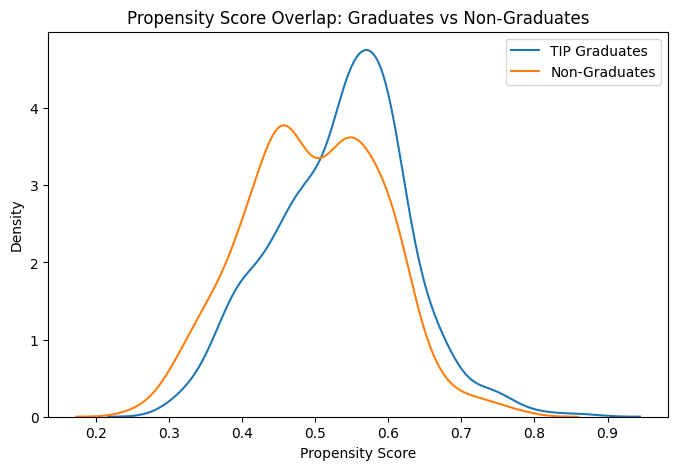


Propensity score summary by treatment:
           count      mean       std       min       25%       50%       75%  \
treatment                                                                      
0          584.0  0.497315  0.093982  0.251706  0.432498  0.496379  0.566472   
1          624.0  0.534434  0.091485  0.292266  0.470177  0.543975  0.593697   

                max  
treatment            
0          0.781090  
1          0.868669  


In [52]:
# 3. Estimate propensity scores and inspect overlap

# Propensity score model uses pre-treatment covariates only
psm_covariates = X_values.drop(columns=['treatment']).copy()

psm_model = LogisticRegression(max_iter=2000, random_state=42)
psm_model.fit(psm_covariates, analysis_df['treatment'])

psm_diagnostics = psm_covariates.copy()
psm_diagnostics['pscore'] = psm_model.predict_proba(psm_covariates)[:, 1]
psm_diagnostics['treatment'] = analysis_df['treatment'].astype(int).values

plt.figure(figsize=(8, 5))
sns.kdeplot(
    psm_diagnostics.loc[psm_diagnostics['treatment'] == 1, 'pscore'],
    label='TIP Graduates'
)
sns.kdeplot(
    psm_diagnostics.loc[psm_diagnostics['treatment'] == 0, 'pscore'],
    label='Non-Graduates'
)
plt.xlabel('Propensity Score')
plt.ylabel('Density')
plt.title('Propensity Score Overlap: Graduates vs Non-Graduates')
plt.legend()
plt.show()

print("\nPropensity score summary by treatment:")
print(psm_diagnostics.groupby('treatment')['pscore'].describe())

In [53]:
# 4. Run naive logistic regression for employment

X_logit = sm.add_constant(X_values.copy())

logit_has_employment = sm.Logit(Y_has_employment, X_logit).fit()
logit_has_employment.summary()

         Current function value: 0.370700
         Iterations: 35


c:\Program Files\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:     employment_outcome   No. Observations:                 1208
Model:                          Logit   Df Residuals:                     1190
Method:                           MLE   Df Model:                           17
Date:                Thu, 26 Mar 2026   Pseudo R-squ.:                  0.4344
Time:                        01:05:55   Log-Likelihood:                -447.81
converged:                      False   LL-Null:                       -791.67
Covariance Type:            nonrobust   LLR p-value:                3.526e-135
==============================================================================================
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                          0.3567      0.376      0.949      0.343      -0.380       1.093
treatment                      0.5623      0.174      3.224      0.001       0.220       0.904
year_TIP                       1.9080      0.164     11.600      0.000       1.586       2.230
any_sentence_before_start      0.0231      0.247      0.093      0.926      -0.462       0.508
any_arrest_before_start        0.6201      0.285      2.175      0.030       0.061       1.179
job_right_before_tip           0.8671      0.281      3.089      0.002       0.317       1.417
num_sentences_before_start    -0.1439      0.117     -1.225      0.221      -0.374       0.086
num_arrests_before_start      -0.0031      0.125     -0.025      0.980      -0.248       0.242
earnings_two_years_prior       0.6103      0.254      2.399      0.016       0.112       1.109
cohort_2022_2                 -2.1977      0.350     -6.276      0.000      -2.884      -1.511
age_band_25-34                -0.0115      0.200     -0.057      0.954      -0.403       0.380
age_band_35+                  -0.1323      0.236     -0.561      0.575      -0.595       0.330
age_band_<18                 -21.0600    1.2e+04     -0.002      0.999   -2.35e+04    2.35e+04
race_Other                     0.3357      1.550      0.217      0.829      -2.703       3.374
race_Unknown                  -2.9133      1.140     -2.556      0.011      -5.147      -0.679
race_White                     0.4630      0.278      1.667      0.095      -0.081       1.007
gender_Male                    0.4495      0.328      1.371      0.171      -0.193       1.092
gender_Unknown               -17.4675   3138.937     -0.006      0.996   -6169.672    6134.737
==============================================================================================
"""

In [54]:
# 5. Display coefficients and sample counts

logit_has_employment_summary = (
    logit_has_employment.summary2().tables[1].reset_index()
)

print(logit_has_employment_summary[['index', 'Coef.', 'P>|z|']])

print("\nTreatment counts:")
print(analysis_df['treatment'].value_counts(dropna=False))

print("\nStatus counts:")
print(analysis_df['Status'].value_counts(dropna=False))

                         index      Coef.         P>|z|
0                        const   0.356707  3.425525e-01
1                    treatment   0.562264  1.263133e-03
2                     year_TIP   1.907974  4.143876e-31
3    any_sentence_before_start   0.023134  9.255064e-01
4      any_arrest_before_start   0.620103  2.964308e-02
5         job_right_before_tip   0.867111  2.009599e-03
6   num_sentences_before_start  -0.143903  2.206421e-01
7     num_arrests_before_start  -0.003071  9.803745e-01
8     earnings_two_years_prior   0.610254  1.642129e-02
9                cohort_2022_2  -2.197661  3.473339e-10
10              age_band_25-34  -0.011482  9.541818e-01
11                age_band_35+  -0.132262  5.749917e-01
12                age_band_<18 -21.060042  9.985976e-01
13                  race_Other   0.335681  8.285768e-01
14                race_Unknown  -2.913279  1.059390e-02
15                  race_White   0.462976  9.543577e-02
16                 gender_Male   0.449535  1.705

The current naive employment model is:

$$
\text{logit}(p_e) =
\beta_0 + \beta_1(\text{treatment}) + \beta_2(\text{year\_TIP}) +
\beta_3(\text{any\_sentence\_before\_start}) +
\\beta_4(\text{any\_arrest\_before\_start}) +
\beta_5(\text{job\_right\_before\_tip}) +
\beta_6(\text{num\_sentences\_before\_start}) +
\\beta_7(\text{num\_arrests\_before\_start}) +
\beta_8(\text{earnings\_two\_years\_prior}) + \gamma'Z
$$

where \(Z\) includes indicator variables for:

- cohort\_2022
- age band
- race
- gender

This model is descriptive and is used only as a preliminary diagnostic before formal matching. The propensity score model in this section uses the same pre-TIP covariates and demographic variables, excluding treatment itself, to evaluate overlap between graduates and non-graduates.

## Matching

In [57]:
matching_df = grad_non_grad.copy()

# Keep needed variables
matching_df = matching_df[
    [
        'tip_id',
        'Status',
        'treatment',
        'StartDate',
        'year_TIP',
        'cohort_2022',
        'age_at_start',
        'age_band',
        'race',
        'gender',
        'census_tract',
        'any_sentence_before_start',
        'num_sentences_before_start',
        'max_ogs_before_start',
        'any_high_ogs_before_start',
        'any_arrest_before_start',
        'num_arrests_before_start',
        'earnings_year_prior',
        'earnings_two_years_prior',
        'job_right_before_tip',
        'employment_outcome',
        'employment_outcome_earnings',
        'offense_outcome',
        'offense_count_post_1_5y',
        'arrest_outcome',
        'arrest_count_post_1_5y'
    ]
].copy()

# Clean matching variables
matching_df = matching_df.dropna(subset=['treatment', 'cohort_2022', 'age_band', 'race', 'gender']).copy()

matching_df['treatment'] = matching_df['treatment'].astype(int)
matching_df['cohort_2022'] = matching_df['cohort_2022'].astype(int)
matching_df['age_band'] = matching_df['age_band'].astype(str)
matching_df['race'] = matching_df['race'].astype(str)
matching_df['gender'] = matching_df['gender'].astype(str)

print("matching_df shape:", matching_df.shape)
print("\nTreatment counts:")
print(matching_df['treatment'].value_counts(dropna=False))

print("\nExact-match strata counts:")
print(
    matching_df.groupby(['cohort_2022', 'race', 'gender', 'age_band', 'treatment'])
    .size()
    .reset_index(name='n')
    .sort_values(['cohort_2022', 'race', 'gender', 'age_band', 'treatment'])
)

matching_df shape: (1208, 26)

Treatment counts:
treatment
1    624
0    584
Name: count, dtype: int64

Exact-match strata counts:
    cohort_2022   race  gender age_band  treatment   n
0             1  Black  Female    18-24          0   8
1             1  Black  Female    18-24          1   9
2             1  Black  Female    25-34          0  16
3             1  Black  Female    25-34          1   8
4             1  Black  Female      35+          0   4
..          ...    ...     ...      ...        ...  ..
61            2  White    Male    18-24          1   1
62            2  White    Male    25-34          0   1
63            2  White    Male    25-34          1   1
64            2  White    Male      35+          0   2
65            2  White    Male      35+          1   1

[66 rows x 6 columns]


In [58]:
psm_df = matching_df.copy()

# Covariates for propensity score model
psm_covariates = psm_df[
    [
        'year_TIP',
        'any_sentence_before_start',
        'num_sentences_before_start',
        'max_ogs_before_start',
        'any_high_ogs_before_start',
        'any_arrest_before_start',
        'num_arrests_before_start',
        'earnings_year_prior',
        'earnings_two_years_prior',
        'job_right_before_tip'
    ]
].copy()

# Standardize continuous variables
continuous_vars = [
    'year_TIP',
    'num_sentences_before_start',
    'max_ogs_before_start',
    'num_arrests_before_start',
    'earnings_year_prior',
    'earnings_two_years_prior'
]

scaler = StandardScaler()
psm_covariates[continuous_vars] = scaler.fit_transform(psm_covariates[continuous_vars])

# Fit logistic regression for propensity score
psm_model = LogisticRegression(max_iter=2000, random_state=42)
psm_model.fit(psm_covariates, psm_df['treatment'])

psm_df['pscore'] = psm_model.predict_proba(psm_covariates)[:, 1]

print(psm_df['pscore'].describe())

print("\nPropensity score by treatment:")
print(psm_df.groupby('treatment')['pscore'].describe())

count    1208.000000
mean        0.516569
std         0.065649
min         0.287415
25%         0.488590
50%         0.500324
75%         0.553546
max         0.887136
Name: pscore, dtype: float64

Propensity score by treatment:
           count      mean       std       min       25%       50%       75%  \
treatment                                                                      
0          584.0  0.507329  0.064649  0.287415  0.484726  0.498452  0.539613   
1          624.0  0.525217  0.065451  0.336466  0.490523  0.502124  0.567104   

                max  
treatment            
0          0.887136  
1          0.865390  


In [59]:
def nearest_neighbor_match_within_strata(
    df,
    exact_vars,
    treatment_col='treatment',
    id_col='tip_id',
    pscore_col='pscore',
    caliper=0.20
):
    """
    1:1 nearest-neighbor matching without replacement
    within exact-match strata, using propensity score distance.

    caliper is applied on the absolute difference in propensity score.
    """
    matched_rows = []
    matched_control_ids = set()

    treated_df = df[df[treatment_col] == 1].copy()
    control_df = df[df[treatment_col] == 0].copy()

    treated_df = treated_df.sort_values(pscore_col).reset_index(drop=True)

    pair_id = 1

    for _, treated_row in treated_df.iterrows():
        strata_mask = np.ones(len(control_df), dtype=bool)

        for var in exact_vars:
            strata_mask &= (control_df[var] == treated_row[var])

        eligible_controls = control_df.loc[strata_mask].copy()

        if len(eligible_controls) == 0:
            continue

        eligible_controls = eligible_controls[
            ~eligible_controls[id_col].isin(matched_control_ids)
        ].copy()

        if len(eligible_controls) == 0:
            continue

        eligible_controls['pscore_diff'] = np.abs(
            eligible_controls[pscore_col] - treated_row[pscore_col]
        )

        eligible_controls = eligible_controls[
            eligible_controls['pscore_diff'] <= caliper
        ].copy()

        if len(eligible_controls) == 0:
            continue

        best_control = eligible_controls.sort_values('pscore_diff').iloc[0]

        treated_out = treated_row.to_dict()
        treated_out['match_pair_id'] = pair_id
        treated_out['match_role'] = 'treated'
        treated_out['matched_to_id'] = best_control[id_col]
        treated_out['match_pscore_diff'] = abs(treated_row[pscore_col] - best_control[pscore_col])

        control_out = best_control.to_dict()
        control_out['match_pair_id'] = pair_id
        control_out['match_role'] = 'control'
        control_out['matched_to_id'] = treated_row[id_col]
        control_out['match_pscore_diff'] = abs(treated_row[pscore_col] - best_control[pscore_col])

        matched_rows.append(treated_out)
        matched_rows.append(control_out)

        matched_control_ids.add(best_control[id_col])
        pair_id += 1

    matched_df = pd.DataFrame(matched_rows)
    return matched_df


exact_match_vars = ['cohort_2022', 'race', 'gender', 'age_band']

matched_grad_non_grad = nearest_neighbor_match_within_strata(
    df=psm_df,
    exact_vars=exact_match_vars,
    treatment_col='treatment',
    id_col='tip_id',
    pscore_col='pscore',
    caliper=0.20
)

print("matched_grad_non_grad shape:", matched_grad_non_grad.shape)
print("\nMatched pair count:", matched_grad_non_grad['match_pair_id'].nunique())

print("\nMatched treatment counts:")
print(matched_grad_non_grad['treatment'].value_counts(dropna=False))

matched_grad_non_grad shape: (954, 32)

Matched pair count: 477

Matched treatment counts:
treatment
1    477
0    477
Name: count, dtype: int64


In [60]:
print("Matched status counts:")
print(matched_grad_non_grad['Status'].value_counts(dropna=False))

print("\nMatched exact strata check:")
print(
    matched_grad_non_grad.groupby(['cohort_2022', 'race', 'gender', 'age_band', 'treatment'])
    .size()
    .reset_index(name='n')
    .sort_values(['cohort_2022', 'race', 'gender', 'age_band', 'treatment'])
)

print("\nAverage propensity score difference within matched pairs:")
print(matched_grad_non_grad[['match_pair_id', 'match_pscore_diff']].drop_duplicates()['match_pscore_diff'].describe())

Matched status counts:
Status
Graduated        477
Non Graduated    477
Name: count, dtype: int64

Matched exact strata check:
    cohort_2022     race   gender age_band  treatment    n
0             1    Black   Female    18-24          0    8
1             1    Black   Female    18-24          1    8
2             1    Black   Female    25-34          0    8
3             1    Black   Female    25-34          1    8
4             1    Black   Female      35+          0    3
5             1    Black   Female      35+          1    3
6             1    Black     Male    18-24          0  111
7             1    Black     Male    18-24          1  111
8             1    Black     Male    25-34          0  139
9             1    Black     Male    25-34          1  139
10            1    Black     Male      35+          0   66
11            1    Black     Male      35+          1   66
12            1  Unknown     Male    25-34          0    1
13            1  Unknown     Male    25-34     

In [61]:
treated_pairs = matched_grad_non_grad[
    matched_grad_non_grad['match_role'] == 'treated'
][
    ['match_pair_id', 'tip_id', 'pscore', 'cohort_2022', 'race', 'gender', 'age_band', 'match_pscore_diff']
].rename(columns={
    'tip_id': 'treated_tip_id',
    'pscore': 'treated_pscore'
})

control_pairs = matched_grad_non_grad[
    matched_grad_non_grad['match_role'] == 'control'
][
    ['match_pair_id', 'tip_id', 'pscore']
].rename(columns={
    'tip_id': 'control_tip_id',
    'pscore': 'control_pscore'
})

matched_pair_summary = treated_pairs.merge(control_pairs, on='match_pair_id', how='inner')

matched_pair_summary.head(20)

,match_pair_id,treated_tip_id,treated_pscore,cohort_2022,race,gender,age_band,match_pscore_diff,control_tip_id,control_pscore
0,1,879,0.336466,1,Black,Male,35+,0.043094,598,0.379560
1,2,861,0.344959,1,Black,Male,25-34,0.005538,1362,0.339421
2,3,1783,0.365352,2,Black,Male,25-34,0.013672,1486,0.379025
3,4,898,0.377926,1,Black,Male,25-34,0.014809,528,0.392735
4,5,431,0.381383,1,Black,Male,25-34,0.018848,1298,0.400231
5,6,868,0.382109,1,Black,Male,25-34,0.018737,1209,0.400846
6,7,726,0.384548,1,Black,Male,25-34,0.020172,857,0.404720
7,8,600,0.392902,1,Black,Male,18-24,0.002050,1254,0.394951
8,9,465,0.395093,1,Black,Male,18-24,0.001389,909,0.396482
9,10,779,0.398299,1,White,Male,25-34,0.072665,1006,0.470964


In [62]:
matched_grad_non_grad = matched_grad_non_grad.sort_values(
    ['match_pair_id', 'match_role']
).reset_index(drop=True)

print("Final matched analysis file shape:", matched_grad_non_grad.shape)

matched_grad_non_grad.head()

Final matched analysis file shape: (954, 32)


,tip_id,Status,treatment,StartDate,year_TIP,cohort_2022,age_at_start,age_band,race,gender,...,offense_outcome,offense_count_post_1_5y,arrest_outcome,arrest_count_post_1_5y,pscore,match_pair_id,match_role,matched_to_id,match_pscore_diff,pscore_diff
0,598,Non Graduated,0,2017-08-21,2017,1,44.0,35+,Black,Male,...,1,2.0,1,2.0,0.379560,1,control,879,0.043094,0.043094
1,879,Graduated,1,2019-02-04,2019,1,35.0,35+,Black,Male,...,1,2.0,0,0.0,0.336466,1,treated,598,0.043094,NaN
2,1362,Non Graduated,0,2021-08-30,2021,1,25.0,25-34,Black,Male,...,0,0.0,0,0.0,0.339421,2,control,861,0.005538,0.005538
3,861,Graduated,1,2019-01-02,2019,1,31.0,25-34,Black,Male,...,0,0.0,1,2.0,0.344959,2,treated,1362,0.005538,NaN
4,1486,Non Graduated,0,2022-03-29,2022,2,27.0,25-34,Black,Male,...,0,0.0,0,0.0,0.379025,3,control,1783,0.013672,0.013672


## Matched Sample Diagnostics and Preliminary Outcome Comparisons

Now that we have constructed the matched graduate vs. non-graduate sample, the next step is to evaluate whether the matched sample is sufficiently balanced and to summarize outcome differences before running formal matched regressions.

This section has two goals.

First, we examine **matched sample diagnostics**. We compare the treatment and control groups on key pre-TIP covariates and compute standardized mean differences (SMDs). This helps us assess whether the matching procedure improved comparability between graduates and non-graduates.

Second, we present **simple matched outcome comparisons**. For the matched sample, we compare average employment, earnings, offense, and arrest outcomes between graduates and non-graduates. These comparisons are descriptive and are intended to show the direction and magnitude of differences after matching.

These results are not yet the final adjusted estimates. If residual imbalance remains for some baseline variables, those variables should be controlled for in the next matched regression step.

In [63]:
matched_analysis = matched_grad_non_grad.copy()

print("Matched sample size:", len(matched_analysis))
print("Matched pair count:", matched_analysis['match_pair_id'].nunique())

print("\nTreatment counts:")
print(matched_analysis['treatment'].value_counts(dropna=False))

print("\nStatus counts:")
print(matched_analysis['Status'].value_counts(dropna=False))

print("\nCohort by treatment:")
print(pd.crosstab(matched_analysis['cohort_2022'], matched_analysis['treatment'], margins=True))

print("\nAge band by treatment:")
print(pd.crosstab(matched_analysis['age_band'], matched_analysis['treatment'], margins=True))

print("\nRace by treatment:")
print(pd.crosstab(matched_analysis['race'], matched_analysis['treatment'], margins=True))

print("\nGender by treatment:")
print(pd.crosstab(matched_analysis['gender'], matched_analysis['treatment'], margins=True))

Matched sample size: 954
Matched pair count: 477

Treatment counts:
treatment
0    477
1    477
Name: count, dtype: int64

Status counts:
Status
Non Graduated    477
Graduated        477
Name: count, dtype: int64

Cohort by treatment:
treatment      0    1  All
cohort_2022               
1            385  385  770
2             92   92  184
All          477  477  954

Age band by treatment:
treatment    0    1  All
age_band                
18-24      185  185  370
25-34      201  201  402
35+         91   91  182
All        477  477  954

Race by treatment:
treatment    0    1  All
race                    
Black      422  422  844
Unknown     17   17   34
White       38   38   76
All        477  477  954

Gender by treatment:
treatment    0    1  All
gender                  
Female      35   35   70
Male       427  427  854
Unknown     15   15   30
All        477  477  954


In [64]:
balance_vars = [
    'year_TIP',
    'any_sentence_before_start',
    'num_sentences_before_start',
    'max_ogs_before_start',
    'any_high_ogs_before_start',
    'any_arrest_before_start',
    'num_arrests_before_start',
    'earnings_year_prior',
    'earnings_two_years_prior',
    'job_right_before_tip'
]

balance_table = matched_analysis.groupby('treatment')[balance_vars].mean().T
balance_table.columns = ['matched_control_mean', 'matched_treated_mean']
balance_table['difference'] = (
    balance_table['matched_treated_mean'] - balance_table['matched_control_mean']
)

balance_table

,matched_control_mean,matched_treated_mean,difference
year_TIP,2018.039832,2018.169811,0.129979
any_sentence_before_start,0.412998,0.345912,-0.067086
num_sentences_before_start,2.016771,1.477987,-0.538784
max_ogs_before_start,2.859539,2.331237,-0.528302
any_high_ogs_before_start,0.293501,0.253669,-0.039832
any_arrest_before_start,0.264151,0.278826,0.014675
num_arrests_before_start,1.165618,1.356394,0.190776
earnings_year_prior,3152.515723,3233.599581,81.083857
earnings_two_years_prior,5524.000000,5683.863732,159.863732
job_right_before_tip,0.280922,0.308176,0.027254


In [65]:
def standardized_mean_diff(df, treatment_col, var):
    treated = df[df[treatment_col] == 1][var].dropna()
    control = df[df[treatment_col] == 0][var].dropna()

    mean_t = treated.mean()
    mean_c = control.mean()

    var_t = treated.var()
    var_c = control.var()

    pooled_sd = np.sqrt((var_t + var_c) / 2)

    if pooled_sd == 0:
        return 0

    return (mean_t - mean_c) / pooled_sd

smd_results = []
for var in balance_vars:
    smd_results.append({
        'variable': var,
        'SMD': standardized_mean_diff(matched_analysis, 'treatment', var)
    })

smd_table = pd.DataFrame(smd_results).sort_values('SMD', key=lambda x: x.abs(), ascending=False)
smd_table

,variable,SMD
2,num_sentences_before_start,-0.174181
3,max_ogs_before_start,-0.140945
1,any_sentence_before_start,-0.138436
4,any_high_ogs_before_start,-0.089346
6,num_arrests_before_start,0.063661
9,job_right_before_tip,0.059752
0,year_TIP,0.039738
5,any_arrest_before_start,0.032968
8,earnings_two_years_prior,0.014157
7,earnings_year_prior,0.012280


Matched pair propensity-score difference summary:
count    477.000000
mean       0.022631
std        0.035208
min        0.000000
25%        0.001931
50%        0.007318
75%        0.031661
max        0.186922
Name: match_pscore_diff, dtype: float64


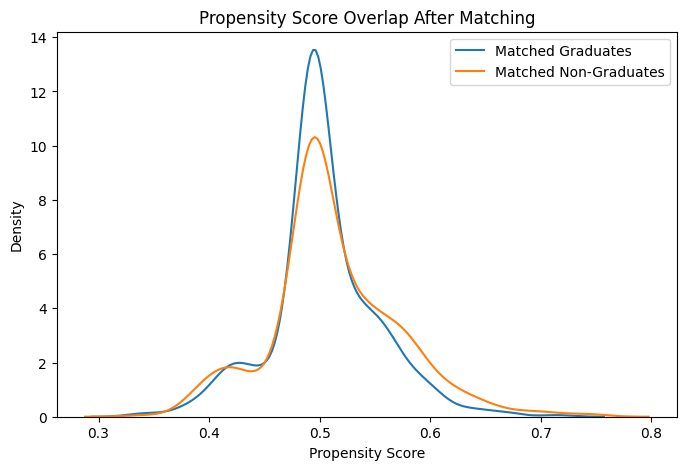

In [66]:
print("Matched pair propensity-score difference summary:")
print(
    matched_analysis[['match_pair_id', 'match_pscore_diff']]
    .drop_duplicates()['match_pscore_diff']
    .describe()
)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.kdeplot(
    matched_analysis.loc[matched_analysis['treatment'] == 1, 'pscore'],
    label='Matched Graduates'
)
sns.kdeplot(
    matched_analysis.loc[matched_analysis['treatment'] == 0, 'pscore'],
    label='Matched Non-Graduates'
)
plt.xlabel('Propensity Score')
plt.ylabel('Density')
plt.title('Propensity Score Overlap After Matching')
plt.legend()
plt.show()

In [67]:
outcome_vars = [
    'employment_outcome',
    'employment_outcome_earnings',
    'offense_outcome',
    'arrest_outcome'
]

matched_outcome_table = matched_analysis.groupby('treatment')[outcome_vars].mean().T
matched_outcome_table.columns = ['matched_control_mean', 'matched_treated_mean']
matched_outcome_table['difference'] = (
    matched_outcome_table['matched_treated_mean'] - matched_outcome_table['matched_control_mean']
)

matched_outcome_table

,matched_control_mean,matched_treated_mean,difference
employment_outcome,0.607966,0.693920,0.085954
employment_outcome_earnings,9487.253669,14422.463312,4935.209644
offense_outcome,0.113208,0.073375,-0.039832
arrest_outcome,0.121593,0.104822,-0.016771


Overall, the matched sample appears usable for downstream analysis. Most standardized mean differences are below 0.10, indicating reasonably good balance after matching. A few justice-history variables remain somewhat imbalanced, especially:

- number of sentences before TIP start
- maximum OGS before TIP start
- any sentence before TIP start

Their absolute SMDs are still above 0.10, although they remain below 0.20. This suggests that the matching procedure substantially improved comparability, but did not fully eliminate all baseline differences in prior justice involvement. As a result, these variables should still be included as controls in the next matched regression models.

The preliminary matched outcome comparisons show a consistent pattern. Relative to matched non-graduates, matched graduates have:

- a higher employment rate within 1.5 years after TIP start
- higher post-TIP earnings
- a lower offense rate
- a slightly lower arrest rate

In substantive terms, the matched descriptive results suggest that graduation from TIP is associated with better labor-market outcomes and somewhat better justice-related outcomes. However, these are still descriptive comparisons within the matched sample. The next step is to estimate regression models on the matched sample, with additional adjustment for the remaining baseline imbalances, to test whether these differences remain after covariate adjustment.

## Matched Regression Analysis

After checking balance and outcome differences in the matched sample, the next step is to estimate regression models on the matched data.

These models serve two purposes. First, they test whether the observed differences between graduates and non-graduates remain after further adjustment for the baseline variables that still show some residual imbalance after matching. Second, they provide a more formal estimate of the association between TIP graduation and post-TIP outcomes within the matched sample.

The matched regressions use the matched graduate vs. non-graduate sample and cluster standard errors by matched pair. We estimate four models:

- a logistic regression for employment within 1.5 years after TIP start
- an OLS regression for post-TIP earnings within 1.5 years
- a logistic regression for offense within 1.5 years
- a logistic regression for arrest within 1.5 years

These matched regressions are more informative than simple matched mean comparisons because they adjust for remaining baseline differences, especially in prior sentencing severity and prior justice involvement.

In [68]:
matched_reg_df = matched_grad_non_grad.copy()

# Keep only variables needed for regression
matched_reg_df = matched_reg_df[
    [
        'tip_id',
        'match_pair_id',
        'match_role',
        'treatment',
        'Status',
        'year_TIP',
        'cohort_2022',
        'age_band',
        'race',
        'gender',
        'any_sentence_before_start',
        'num_sentences_before_start',
        'max_ogs_before_start',
        'any_high_ogs_before_start',
        'any_arrest_before_start',
        'num_arrests_before_start',
        'earnings_year_prior',
        'earnings_two_years_prior',
        'job_right_before_tip',
        'employment_outcome',
        'employment_outcome_earnings',
        'offense_outcome',
        'arrest_outcome'
    ]
].copy()

# Clean categorical variables for regression
matched_reg_df['cohort_2022'] = matched_reg_df['cohort_2022'].astype('Int64').astype(str)
matched_reg_df['age_band'] = matched_reg_df['age_band'].fillna('Unknown').astype(str)
matched_reg_df['race'] = matched_reg_df['race'].fillna('Unknown').astype(str)
matched_reg_df['gender'] = matched_reg_df['gender'].fillna('Unknown').astype(str)

print("matched_reg_df shape:", matched_reg_df.shape)
print("\nMatched pairs:", matched_reg_df['match_pair_id'].nunique())
print("\nTreatment counts:")
print(matched_reg_df['treatment'].value_counts(dropna=False))

matched_reg_df shape: (954, 23)

Matched pairs: 477

Treatment counts:
treatment
0    477
1    477
Name: count, dtype: int64


In [69]:
# Core baseline controls
X_base = matched_reg_df[
    [
        'treatment',
        'year_TIP',
        'any_sentence_before_start',
        'num_sentences_before_start',
        'max_ogs_before_start',
        'any_high_ogs_before_start',
        'any_arrest_before_start',
        'num_arrests_before_start',
        'earnings_year_prior',
        'earnings_two_years_prior',
        'job_right_before_tip'
    ]
].copy()

# Add categorical controls
X_cat = pd.get_dummies(
    matched_reg_df[['cohort_2022', 'age_band', 'race', 'gender']],
    drop_first=True,
    dtype=int
)

X_matched = pd.concat([X_base, X_cat], axis=1)
X_matched = sm.add_constant(X_matched)

print("Design matrix shape:", X_matched.shape)
print("\nColumns:")
print(X_matched.columns.tolist())

Design matrix shape: (954, 19)

Columns:
['const', 'treatment', 'year_TIP', 'any_sentence_before_start', 'num_sentences_before_start', 'max_ogs_before_start', 'any_high_ogs_before_start', 'any_arrest_before_start', 'num_arrests_before_start', 'earnings_year_prior', 'earnings_two_years_prior', 'job_right_before_tip', 'cohort_2022_2', 'age_band_25-34', 'age_band_35+', 'race_Unknown', 'race_White', 'gender_Male', 'gender_Unknown']


In [70]:
Y_employment = matched_reg_df['employment_outcome'].astype(int)

employment_model = sm.Logit(Y_employment, X_matched).fit(
    cov_type='cluster',
    cov_kwds={'groups': matched_reg_df['match_pair_id']}
)

employment_model.summary()

         Current function value: 0.384601
         Iterations: 35


c:\Program Files\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:     employment_outcome   No. Observations:                  954
Model:                          Logit   Df Residuals:                      935
Method:                           MLE   Df Model:                           18
Date:                Thu, 26 Mar 2026   Pseudo R-squ.:                  0.4054
Time:                        01:33:08   Log-Likelihood:                -366.91
converged:                      False   LL-Null:                       -617.11
Covariance Type:              cluster   LLR p-value:                 8.632e-95
==============================================================================================
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                      -1140.6476    118.127     -9.656      0.000   -1372.171    -909.124
treatment                      0.5439      0.193      2.824      0.005       0.166       0.921
year_TIP                       0.5655      0.059      9.645      0.000       0.451       0.680
any_sentence_before_start      0.0568      0.395      0.144      0.886      -0.717       0.831
num_sentences_before_start     0.0348      0.053      0.663      0.507      -0.068       0.138
max_ogs_before_start           0.0149      0.092      0.161      0.872      -0.166       0.196
any_high_ogs_before_start     -0.5900      0.621     -0.951      0.342      -1.806       0.626
any_arrest_before_start        0.8703      0.341      2.550      0.011       0.201       1.539
num_arrests_before_start      -0.0360      0.047     -0.763      0.446      -0.129       0.057
earnings_year_prior            0.0001   5.55e-05      2.290      0.022    1.83e-05       0.000
earnings_two_years_prior   -1.149e-05   2.54e-05     -0.453      0.651   -6.13e-05    3.83e-05
job_right_before_tip           0.5422      0.328      1.651      0.099      -0.101       1.186
cohort_2022_2                 -2.3166      0.417     -5.554      0.000      -3.134      -1.499
age_band_25-34                -0.1268      0.219     -0.578      0.563      -0.557       0.303
age_band_35+                  -0.3012      0.266     -1.133      0.257      -0.822       0.220
race_Unknown                 -21.4556      0.985    -21.790      0.000     -23.386     -19.526
race_White                     0.4243      0.308      1.379      0.168      -0.179       1.027
gender_Male                    0.2753      0.411      0.669      0.503      -0.531       1.082
gender_Unknown                -4.3353      1.126     -3.851      0.000      -6.542      -2.129
==============================================================================================
"""

In [71]:
employment_summary = employment_model.summary2().tables[1].reset_index()
print(employment_summary[['index', 'Coef.', 'Std.Err.', 'P>|z|']])

                         index        Coef.    Std.Err.          P>|z|
0                        const -1140.647628  118.126557   4.629404e-22
1                    treatment     0.543912    0.192577   4.737211e-03
2                     year_TIP     0.565451    0.058626   5.159132e-22
3    any_sentence_before_start     0.056768    0.394935   8.857052e-01
4   num_sentences_before_start     0.034831    0.052502   5.070643e-01
5         max_ogs_before_start     0.014924    0.092480   8.717986e-01
6    any_high_ogs_before_start    -0.589957    0.620501   3.417187e-01
7      any_arrest_before_start     0.870272    0.341237   1.076158e-02
8     num_arrests_before_start    -0.036007    0.047199   4.455408e-01
9          earnings_year_prior     0.000127    0.000055   2.204671e-02
10    earnings_two_years_prior    -0.000011    0.000025   6.508458e-01
11        job_right_before_tip     0.542243    0.328369   9.867271e-02
12               cohort_2022_2    -2.316592    0.417096   2.790564e-08
13    

In [72]:
Y_earnings = matched_reg_df['employment_outcome_earnings'].astype(float)

earnings_model = sm.OLS(Y_earnings, X_matched).fit(
    cov_type='cluster',
    cov_kwds={'groups': matched_reg_df['match_pair_id']}
)

earnings_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:     employment_outcome_earnings   R-squared:                       0.324
Model:                                     OLS   Adj. R-squared:                  0.311
Method:                          Least Squares   F-statistic:                     24.27
Date:                         Thu, 26 Mar 2026   Prob (F-statistic):           4.26e-56
Time:                                 01:33:35   Log-Likelihood:                -10431.
No. Observations:                          954   AIC:                         2.090e+04
Df Residuals:                              935   BIC:                         2.099e+04
Df Model:                                   18                                         
Covariance Type:                       cluster                                         
==============================================================================================
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                      -3.229e+06   3.84e+05     -8.415      0.000   -3.98e+06   -2.48e+06
treatment                   4672.0828    904.297      5.167      0.000    2899.694    6444.471
year_TIP                    1603.3488    190.564      8.414      0.000    1229.850    1976.848
any_sentence_before_start    774.6521   2152.855      0.360      0.719   -3444.866    4994.170
num_sentences_before_start  -203.4731    264.138     -0.770      0.441    -721.174     314.228
max_ogs_before_start         312.8785    504.493      0.620      0.535    -675.909    1301.666
any_high_ogs_before_start  -3355.5735   3264.691     -1.028      0.304   -9754.251    3043.104
any_arrest_before_start     1334.5382   1580.713      0.844      0.399   -1763.603    4432.679
num_arrests_before_start     -28.8612    218.776     -0.132      0.895    -457.654     399.932
earnings_year_prior            0.8002      0.315      2.536      0.011       0.182       1.419
earnings_two_years_prior       0.0964      0.179      0.538      0.591      -0.255       0.447
job_right_before_tip       -2409.3739   1437.488     -1.676      0.094   -5226.799     408.051
cohort_2022_2              -1081.3982   1718.168     -0.629      0.529   -4448.945    2286.148
age_band_25-34              1021.0801    932.779      1.095      0.274    -807.134    2849.294
age_band_35+                1074.2988   1383.853      0.776      0.438   -1638.003    3786.600
race_Unknown               -1.014e+04   4224.881     -2.400      0.016   -1.84e+04   -1857.159
race_White                  1313.6560   1639.565      0.801      0.423   -1899.833    4527.145
gender_Male                 -294.6193   2035.268     -0.145      0.885   -4283.671    3694.432
gender_Unknown              2444.1633   4887.666      0.500      0.617   -7135.487     1.2e+04
==============================================================================
Omnibus:                      277.473   Durbin-Watson:                   1.982
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              891.478
Skew:                           1.411   Prob(JB):                    2.62e-194
Kurtosis:                       6.803   Cond. No.                     1.32e+07
==============================================================================

Notes:
[1] Standard Errors are robust to cluster correlation (cluster)
[2] The condition number is large, 1.32e+07. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [79]:
earnings_summary = earnings_model.summary2().tables[1].reset_index()
print(earnings_summary[['index', 'Coef.', 'Std.Err.', 'P>|z|']])

                         index         Coef.       Std.Err.         P>|z|
0                        const -3.228634e+06  383693.058036  3.941486e-17
1                    treatment  4.672083e+03     904.296533  2.384692e-07
2                     year_TIP  1.603349e+03     190.564099  3.972832e-17
3    any_sentence_before_start  7.746521e+02    2152.854998  7.189776e-01
4   num_sentences_before_start -2.034731e+02     264.138134  4.411051e-01
5         max_ogs_before_start  3.128785e+02     504.492816  5.351365e-01
6    any_high_ogs_before_start -3.355573e+03    3264.691432  3.040261e-01
7      any_arrest_before_start  1.334538e+03    1580.713282  3.985223e-01
8     num_arrests_before_start -2.886121e+01     218.775859  8.950465e-01
9          earnings_year_prior  8.001845e-01       0.315478  1.119934e-02
10    earnings_two_years_prior  9.635284e-02       0.179114  5.906181e-01
11        job_right_before_tip -2.409374e+03    1437.488340  9.371865e-02
12               cohort_2022_2 -1.0813

In [75]:
Y_offense = matched_reg_df['offense_outcome'].astype(int)

offense_model = sm.Logit(Y_offense, X_matched).fit(
    cov_type='cluster',
    cov_kwds={'groups': matched_reg_df['match_pair_id']}
)

offense_model.summary()

         Current function value: 0.237801
         Iterations: 35


c:\Program Files\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:        offense_outcome   No. Observations:                  954
Model:                          Logit   Df Residuals:                      935
Method:                           MLE   Df Model:                           18
Date:                Thu, 26 Mar 2026   Pseudo R-squ.:                  0.2331
Time:                        01:34:22   Log-Likelihood:                -226.86
converged:                      False   LL-Null:                       -295.82
Covariance Type:              cluster   LLR p-value:                 1.609e-20
==============================================================================================
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                        241.8210    128.971      1.875      0.061     -10.958     494.600
treatment                     -0.7384      0.253     -2.918      0.004      -1.234      -0.242
year_TIP                      -0.1220      0.064     -1.908      0.056      -0.247       0.003
any_sentence_before_start      1.1185      0.478      2.340      0.019       0.182       2.055
num_sentences_before_start    -0.0766      0.060     -1.279      0.201      -0.194       0.041
max_ogs_before_start           0.0064      0.108      0.060      0.952      -0.205       0.218
any_high_ogs_before_start     -0.1315      0.632     -0.208      0.835      -1.369       1.106
any_arrest_before_start        1.9959      0.361      5.535      0.000       1.289       2.703
num_arrests_before_start       0.0559      0.039      1.440      0.150      -0.020       0.132
earnings_year_prior          4.41e-05   7.14e-05      0.617      0.537   -9.59e-05       0.000
earnings_two_years_prior   -2.747e-05    4.2e-05     -0.654      0.513      -0.000    5.49e-05
job_right_before_tip          -0.1885      0.378     -0.499      0.618      -0.929       0.552
cohort_2022_2                 -1.8176      0.722     -2.518      0.012      -3.233      -0.403
age_band_25-34                -0.2935      0.287     -1.022      0.307      -0.857       0.270
age_band_35+                  -0.1214      0.320     -0.379      0.704      -0.749       0.506
race_Unknown                 -18.9560      0.985    -19.251      0.000     -20.886     -17.026
race_White                     0.4454      0.393      1.132      0.258      -0.326       1.216
gender_Male                    1.2965      1.038      1.249      0.212      -0.737       3.331
gender_Unknown                -4.1480      1.430     -2.900      0.004      -6.952      -1.344
==============================================================================================
"""

In [76]:
offense_summary = offense_model.summary2().tables[1].reset_index()
print(offense_summary[['index', 'Coef.', 'Std.Err.', 'P>|z|']])

                         index       Coef.    Std.Err.         P>|z|
0                        const  241.821048  128.971287  6.079285e-02
1                    treatment   -0.738408    0.253079  3.526272e-03
2                     year_TIP   -0.121964    0.063938  5.645012e-02
3    any_sentence_before_start    1.118467    0.477914  1.926765e-02
4   num_sentences_before_start   -0.076628    0.059933  2.010546e-01
5         max_ogs_before_start    0.006435    0.107759  9.523789e-01
6    any_high_ogs_before_start   -0.131476    0.631620  8.351066e-01
7      any_arrest_before_start    1.995864    0.360565  3.105516e-08
8     num_arrests_before_start    0.055939    0.038850  1.499078e-01
9          earnings_year_prior    0.000044    0.000071  5.369349e-01
10    earnings_two_years_prior   -0.000027    0.000042  5.132454e-01
11        job_right_before_tip   -0.188469    0.377739  6.178219e-01
12               cohort_2022_2   -1.817635    0.721952  1.181355e-02
13              age_band_25-34   -

In [77]:
Y_arrest = matched_reg_df['arrest_outcome'].astype(int)

arrest_model = sm.Logit(Y_arrest, X_matched).fit(
    cov_type='cluster',
    cov_kwds={'groups': matched_reg_df['match_pair_id']}
)

arrest_model.summary()

         Current function value: 0.319650
         Iterations: 35


c:\Program Files\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:         arrest_outcome   No. Observations:                  954
Model:                          Logit   Df Residuals:                      935
Method:                           MLE   Df Model:                           18
Date:                Thu, 26 Mar 2026   Pseudo R-squ.:                 0.09491
Time:                        01:34:48   Log-Likelihood:                -304.95
converged:                      False   LL-Null:                       -336.92
Covariance Type:              cluster   LLR p-value:                 4.626e-07
==============================================================================================
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                       -143.8261     89.082     -1.615      0.106    -318.423      30.771
treatment                     -0.1747      0.214     -0.817      0.414      -0.594       0.244
year_TIP                       0.0694      0.044      1.571      0.116      -0.017       0.156
any_sentence_before_start      0.9006      0.409      2.205      0.027       0.100       1.701
num_sentences_before_start    -0.0223      0.055     -0.403      0.687      -0.131       0.086
max_ogs_before_start           0.0614      0.086      0.711      0.477      -0.108       0.230
any_high_ogs_before_start     -0.5657      0.537     -1.053      0.293      -1.619       0.488
any_arrest_before_start        1.0275      0.294      3.494      0.000       0.451       1.604
num_arrests_before_start      -0.0635      0.043     -1.493      0.135      -0.147       0.020
earnings_year_prior        -2.526e-05   3.92e-05     -0.644      0.520      -0.000    5.16e-05
earnings_two_years_prior    9.371e-06    2.3e-05      0.408      0.683   -3.57e-05    5.44e-05
job_right_before_tip           0.3742      0.296      1.266      0.205      -0.205       0.953
cohort_2022_2                 -0.5101      0.336     -1.520      0.128      -1.168       0.148
age_band_25-34                -0.1334      0.255     -0.522      0.602      -0.634       0.367
age_band_35+                  -0.3351      0.328     -1.022      0.307      -0.978       0.308
race_Unknown                 -17.6912        nan        nan        nan         nan         nan
race_White                    -0.1713      0.481     -0.356      0.722      -1.114       0.771
gender_Male                    1.3126      0.761      1.724      0.085      -0.180       2.805
gender_Unknown                18.4359        nan        nan        nan         nan         nan
==============================================================================================
"""

In [78]:
arrest_summary = arrest_model.summary2().tables[1].reset_index()
print(arrest_summary[['index', 'Coef.', 'Std.Err.', 'P>|z|']])

                         index       Coef.   Std.Err.     P>|z|
0                        const -143.826108  89.081781  0.106410
1                    treatment   -0.174651   0.213810  0.414013
2                     year_TIP    0.069392   0.044158  0.116077
3    any_sentence_before_start    0.900639   0.408514  0.027477
4   num_sentences_before_start   -0.022276   0.055227  0.686683
5         max_ogs_before_start    0.061375   0.086273  0.476834
6    any_high_ogs_before_start   -0.565659   0.537395  0.292527
7      any_arrest_before_start    1.027506   0.294080  0.000476
8     num_arrests_before_start   -0.063469   0.042500  0.135339
9          earnings_year_prior   -0.000025   0.000039  0.519554
10    earnings_two_years_prior    0.000009   0.000023  0.683350
11        job_right_before_tip    0.374209   0.295502  0.205387
12               cohort_2022_2   -0.510075   0.335534  0.128464
13              age_band_25-34   -0.133361   0.255481  0.601670
14                age_band_35+   -0.3351

## Refined Matched Logit Models for Employment and Offense

The initial matched logistic regression models did not fully converge, likely because the specification included several sparse categorical indicators that were already incorporated into the matching procedure.

To obtain more stable post-matching estimates, we now re-estimate the employment and offense models using a more parsimonious specification. In these refined models, we retain treatment and the main baseline covariates related to prior justice involvement, prior labor market history, and timing, while dropping the categorical variables that were already used for exact matching.

The goal is to test whether the treatment coefficient remains stable in sign and statistical significance under a simpler and more robust post-matching specification.

In [80]:
matched_logit_df = matched_grad_non_grad.copy()

matched_logit_df = matched_logit_df[
    [
        'tip_id',
        'match_pair_id',
        'treatment',
        'year_TIP',
        'any_sentence_before_start',
        'num_sentences_before_start',
        'max_ogs_before_start',
        'any_arrest_before_start',
        'num_arrests_before_start',
        'earnings_two_years_prior',
        'job_right_before_tip',
        'employment_outcome',
        'offense_outcome'
    ]
].copy()

print("matched_logit_df shape:", matched_logit_df.shape)
print("\nMatched pairs:", matched_logit_df['match_pair_id'].nunique())
print("\nTreatment counts:")
print(matched_logit_df['treatment'].value_counts(dropna=False))

matched_logit_df shape: (954, 13)

Matched pairs: 477

Treatment counts:
treatment
0    477
1    477
Name: count, dtype: int64


In [81]:
X_simple = matched_logit_df[
    [
        'treatment',
        'year_TIP',
        'any_sentence_before_start',
        'num_sentences_before_start',
        'max_ogs_before_start',
        'any_arrest_before_start',
        'num_arrests_before_start',
        'earnings_two_years_prior',
        'job_right_before_tip'
    ]
].copy()

X_simple = sm.add_constant(X_simple)

print(X_simple.head())
print("\nColumns:")
print(X_simple.columns.tolist())

   const  treatment  year_TIP  any_sentence_before_start  \
0    1.0          0      2017                        0.0   
1    1.0          1      2019                        1.0   
2    1.0          0      2021                        1.0   
3    1.0          1      2019                        0.0   
4    1.0          0      2022                        1.0   

   num_sentences_before_start  max_ogs_before_start  any_arrest_before_start  \
0                         0.0                   0.0                      1.0   
1                         5.0                   5.0                      1.0   
2                         9.0                   6.0                      1.0   
3                         0.0                   0.0                      1.0   
4                         6.0                   6.0                      1.0   

   num_arrests_before_start  earnings_two_years_prior  job_right_before_tip  
0                       7.0                       0.0                   0.0  
1 

In [82]:
Y_emp_simple = matched_logit_df['employment_outcome'].astype(int)

employment_model_simple = sm.Logit(Y_emp_simple, X_simple).fit(
    maxiter=200,
    disp=False,
    cov_type='cluster',
    cov_kwds={'groups': matched_logit_df['match_pair_id']}
)

print(employment_model_simple.summary())

                           Logit Regression Results                           
Dep. Variable:     employment_outcome   No. Observations:                  954
Model:                          Logit   Df Residuals:                      944
Method:                           MLE   Df Model:                            9
Date:                Thu, 26 Mar 2026   Pseudo R-squ.:                  0.3217
Time:                        01:45:42   Log-Likelihood:                -418.61
converged:                       True   LL-Null:                       -617.11
Covariance Type:              cluster   LLR p-value:                 6.011e-80
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                       -640.8231     76.693     -8.356      0.000    -791.140    -490.507
treatment                      0.4723      0.166      2.843      0.004       0.147 

In [83]:
employment_simple_summary = employment_model_simple.summary2().tables[1].reset_index()
print(employment_simple_summary[['index', 'Coef.', 'Std.Err.', 'P>|z|']])

                        index       Coef.   Std.Err.         P>|z|
0                       const -640.823137  76.693449  6.507684e-17
1                   treatment    0.472253   0.166129  4.473601e-03
2                    year_TIP    0.317489   0.038047  7.138449e-17
3   any_sentence_before_start    0.310799   0.378447  4.115042e-01
4  num_sentences_before_start    0.014434   0.050279  7.740469e-01
5        max_ogs_before_start   -0.049951   0.055797  3.706668e-01
6     any_arrest_before_start    1.225242   0.317533  1.140235e-04
7    num_arrests_before_start   -0.043182   0.046351  3.515297e-01
8    earnings_two_years_prior    0.000062   0.000026  1.756251e-02
9        job_right_before_tip    1.000605   0.280294  3.571960e-04


In [84]:
Y_offense_simple = matched_logit_df['offense_outcome'].astype(int)

offense_model_simple = sm.Logit(Y_offense_simple, X_simple).fit(
    maxiter=200,
    disp=False,
    cov_type='cluster',
    cov_kwds={'groups': matched_logit_df['match_pair_id']}
)

print(offense_model_simple.summary())

                           Logit Regression Results                           
Dep. Variable:        offense_outcome   No. Observations:                  954
Model:                          Logit   Df Residuals:                      944
Method:                           MLE   Df Model:                            9
Date:                Thu, 26 Mar 2026   Pseudo R-squ.:                  0.2031
Time:                        01:46:13   Log-Likelihood:                -235.73
converged:                       True   LL-Null:                       -295.82
Covariance Type:              cluster   LLR p-value:                 1.228e-21
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                        451.6447     96.152      4.697      0.000     263.189     640.100
treatment                     -0.7267      0.245     -2.964      0.003      -1.207 

In [85]:
offense_simple_summary = offense_model_simple.summary2().tables[1].reset_index()
print(offense_simple_summary[['index', 'Coef.', 'Std.Err.', 'P>|z|']])

                        index       Coef.   Std.Err.         P>|z|
0                       const  451.644694  96.152377  2.637824e-06
1                   treatment   -0.726701   0.245138  3.032140e-03
2                    year_TIP   -0.225561   0.047743  2.306480e-06
3   any_sentence_before_start    1.192489   0.435245  6.147466e-03
4  num_sentences_before_start   -0.088865   0.057728  1.237137e-01
5        max_ogs_before_start   -0.012914   0.059626  8.285374e-01
6     any_arrest_before_start    2.289727   0.374376  9.588045e-10
7    num_arrests_before_start    0.042781   0.038499  2.664616e-01
8    earnings_two_years_prior   -0.000004   0.000012  7.338207e-01
9        job_right_before_tip   -0.034864   0.332535  9.165008e-01


## Linear Probability Model for Arrest Outcome

Because the arrest outcome is relatively sparse and the earlier matched logit specification was not stable, we estimate a linear probability model (LPM) for arrest within 1.5 years after TIP start.

This model uses the matched sample and retains the same core baseline covariates as the refined post-matching logit models. Standard errors are clustered by matched pair. The LPM provides a more stable specification for the arrest outcome and allows the treatment coefficient to be interpreted directly as an adjusted percentage-point difference in arrest probability within the matched sample.

In [86]:
matched_arrest_lpm_df = matched_grad_non_grad.copy()

matched_arrest_lpm_df = matched_arrest_lpm_df[
    [
        'tip_id',
        'match_pair_id',
        'treatment',
        'year_TIP',
        'any_sentence_before_start',
        'num_sentences_before_start',
        'max_ogs_before_start',
        'any_arrest_before_start',
        'num_arrests_before_start',
        'earnings_two_years_prior',
        'job_right_before_tip',
        'arrest_outcome'
    ]
].copy()

print("matched_arrest_lpm_df shape:", matched_arrest_lpm_df.shape)
print("\nMatched pairs:", matched_arrest_lpm_df['match_pair_id'].nunique())
print("\nTreatment counts:")
print(matched_arrest_lpm_df['treatment'].value_counts(dropna=False))
print("\nArrest outcome mean:")
print(matched_arrest_lpm_df['arrest_outcome'].mean())

matched_arrest_lpm_df shape: (954, 12)

Matched pairs: 477

Treatment counts:
treatment
0    477
1    477
Name: count, dtype: int64

Arrest outcome mean:
0.11320754716981132


In [87]:
X_arrest_lpm = matched_arrest_lpm_df[
    [
        'treatment',
        'year_TIP',
        'any_sentence_before_start',
        'num_sentences_before_start',
        'max_ogs_before_start',
        'any_arrest_before_start',
        'num_arrests_before_start',
        'earnings_two_years_prior',
        'job_right_before_tip'
    ]
].copy()

X_arrest_lpm = sm.add_constant(X_arrest_lpm)

Y_arrest_lpm = matched_arrest_lpm_df['arrest_outcome'].astype(float)

print(X_arrest_lpm.head())

   const  treatment  year_TIP  any_sentence_before_start  \
0    1.0          0      2017                        0.0   
1    1.0          1      2019                        1.0   
2    1.0          0      2021                        1.0   
3    1.0          1      2019                        0.0   
4    1.0          0      2022                        1.0   

   num_sentences_before_start  max_ogs_before_start  any_arrest_before_start  \
0                         0.0                   0.0                      1.0   
1                         5.0                   5.0                      1.0   
2                         9.0                   6.0                      1.0   
3                         0.0                   0.0                      1.0   
4                         6.0                   6.0                      1.0   

   num_arrests_before_start  earnings_two_years_prior  job_right_before_tip  
0                       7.0                       0.0                   0.0  
1 

In [88]:
arrest_lpm_model = sm.OLS(Y_arrest_lpm, X_arrest_lpm).fit(
    cov_type='cluster',
    cov_kwds={'groups': matched_arrest_lpm_df['match_pair_id']}
)

print(arrest_lpm_model.summary())

                            OLS Regression Results                            
Dep. Variable:         arrest_outcome   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.053
Method:                 Least Squares   F-statistic:                     4.970
Date:                Thu, 26 Mar 2026   Prob (F-statistic):           2.10e-06
Time:                        01:50:51   Log-Likelihood:                -226.64
No. Observations:                 954   AIC:                             473.3
Df Residuals:                     944   BIC:                             521.9
Df Model:                           9                                         
Covariance Type:              cluster                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

In [89]:
arrest_lpm_summary = arrest_lpm_model.summary2().tables[1].reset_index()
print(arrest_lpm_summary[['index', 'Coef.', 'Std.Err.', 'P>|z|']])

                        index         Coef.  Std.Err.     P>|z|
0                       const -2.511463e+00  5.684416  0.658623
1                   treatment -1.410652e-02  0.019645  0.472718
2                    year_TIP  1.269876e-03  0.002821  0.652547
3   any_sentence_before_start  1.073126e-01  0.052897  0.042487
4  num_sentences_before_start -4.899641e-03  0.007297  0.501949
5        max_ogs_before_start -4.946707e-04  0.007880  0.949948
6     any_arrest_before_start  1.459649e-01  0.039739  0.000240
7    num_arrests_before_start -8.885503e-03  0.005441  0.102425
8    earnings_two_years_prior -3.487259e-07  0.000001  0.787016
9        job_right_before_tip  3.951032e-02  0.030455  0.194519


In [90]:
matched_arrest_lpm_df = matched_grad_non_grad.copy()

matched_arrest_lpm_df = matched_arrest_lpm_df[
    [
        'tip_id',
        'match_pair_id',
        'treatment',
        'year_TIP',
        'any_sentence_before_start',
        'num_sentences_before_start',
        'max_ogs_before_start',
        'any_arrest_before_start',
        'num_arrests_before_start',
        'earnings_two_years_prior',
        'job_right_before_tip',
        'arrest_outcome'
    ]
].copy()

scale_cols = [
    'year_TIP',
    'num_sentences_before_start',
    'max_ogs_before_start',
    'num_arrests_before_start',
    'earnings_two_years_prior'
]

scaler = StandardScaler()
matched_arrest_lpm_df[scale_cols] = scaler.fit_transform(
    matched_arrest_lpm_df[scale_cols]
)

X_arrest_lpm_std = matched_arrest_lpm_df[
    [
        'treatment',
        'year_TIP',
        'any_sentence_before_start',
        'num_sentences_before_start',
        'max_ogs_before_start',
        'any_arrest_before_start',
        'num_arrests_before_start',
        'earnings_two_years_prior',
        'job_right_before_tip'
    ]
].copy()

X_arrest_lpm_std = sm.add_constant(X_arrest_lpm_std)
Y_arrest_lpm = matched_arrest_lpm_df['arrest_outcome'].astype(float)

arrest_lpm_std = sm.OLS(Y_arrest_lpm, X_arrest_lpm_std).fit(
    cov_type='cluster',
    cov_kwds={'groups': matched_arrest_lpm_df['match_pair_id']}
)

print(arrest_lpm_std.summary())

                            OLS Regression Results                            
Dep. Variable:         arrest_outcome   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.053
Method:                 Least Squares   F-statistic:                     4.970
Date:                Thu, 26 Mar 2026   Prob (F-statistic):           2.10e-06
Time:                        01:56:58   Log-Likelihood:                -226.64
No. Observations:                 954   AIC:                             473.3
Df Residuals:                     944   BIC:                             521.9
Df Model:                           9                                         
Covariance Type:              cluster                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

## Matched Regression Results

After constructing the matched graduate vs. non-graduate sample, we estimated post-matching regression models to test whether the observed outcome differences remained after adjusting for baseline covariates. The final specifications retained treatment and a parsimonious set of pre-TIP controls related to prior justice involvement, labor market history, and timing. For the binary employment and offense outcomes, the refined matched logit models converged successfully. For the arrest outcome, the linear probability model was used as a more stable specification.

### Employment Outcome

The matched employment logit model shows that graduation from TIP remains positively associated with employment within 1.5 years after TIP start. The coefficient on **treatment** is **0.4723** with a **p-value of 0.004**, indicating a statistically significant positive association. In odds-ratio terms, this corresponds to approximately **1.60 times higher odds of employment** for graduates relative to matched non-graduates \((e^{0.4723} \approx 1.60)\).

This adjusted result is consistent with the descriptive matched comparison. In the matched sample, the employment rate was **0.6939** for graduates and **0.6080** for non-graduates, a difference of **0.0860**, or about **8.6 percentage points**. Taken together, both the descriptive and regression results indicate that graduates had meaningfully better labor-market outcomes after TIP.

Several additional baseline variables were also associated with employment. **year_TIP** was positive and highly significant (**0.3175, p < 0.001**), suggesting stronger employment outcomes in later TIP years. **any_arrest_before_start** was also positive (**1.2252, p < 0.001**), while **earnings_two_years_prior** (**0.00006196, p = 0.018**) and **job_right_before_tip** (**1.0006, p < 0.001**) were positively associated with post-TIP employment.

### Earnings Outcome

The matched OLS model for post-TIP earnings also shows a strong positive association between graduation and earnings. The coefficient on **treatment** is **4672.083** with a **p-value of 2.38e-07**, indicating that graduates earned about **$4,672 more** than matched non-graduates within 1.5 years after TIP start, conditional on the included covariates.

This adjusted estimate closely matches the descriptive matched comparison. In the matched sample, mean post-TIP earnings were **14,422.46** for graduates and **9,487.25** for non-graduates, a difference of **4,935.21**. Thus, both the raw matched comparison and the adjusted model point to substantially better earnings outcomes among graduates.

The earnings model had an **R-squared of 0.324**, indicating moderate explanatory power. In addition to treatment, **year_TIP** was positively associated with earnings (**1603.349, p < 0.001**), and **earnings_year_prior** was also positive and statistically significant (**0.8002, p = 0.012**).

### Offense Outcome

The refined matched offense logit model also converged successfully and indicates a statistically significant negative association between graduation and post-TIP offense. The coefficient on **treatment** is **-0.7267** with a **p-value of 0.003**. In odds-ratio terms, this corresponds to approximately **0.48 times the odds of offense** for graduates relative to matched non-graduates \((e^{-0.7267} \approx 0.48)\), or roughly a **52% reduction in the odds of offense**.

Again, this is consistent with the descriptive matched comparison. In the matched sample, the offense rate was **0.0734** for graduates and **0.1132** for non-graduates, a difference of **-0.0398**, or about **4.0 percentage points**. Together, these results suggest that graduation is associated not only with better employment outcomes, but also with lower post-TIP offense risk.

Other significant predictors of post-TIP offense include **year_TIP** (**-0.2256, p < 0.001**), indicating lower offense risk in later years, as well as **any_sentence_before_start** (**1.1925, p = 0.006**) and **any_arrest_before_start** (**2.2897, p < 0.001**), both of which were associated with higher post-TIP offense risk.

### Arrest Outcome

For arrest, the evidence is weaker. In the matched descriptive comparison, the arrest rate was **0.1048** for graduates and **0.1216** for non-graduates, a difference of **-0.0168**, or about **1.7 percentage points**. This suggests a lower arrest rate among graduates, but the magnitude is much smaller than for employment or offense.

In the matched arrest LPM, the coefficient on **treatment** is **-0.0141** with a **p-value of 0.473**, indicating that the estimated arrest difference is not statistically significant after adjustment. Thus, while the direction remains negative, the arrest outcome does not show robust evidence of a treatment association in the matched analysis.

The arrest model instead suggests that prior justice history is more predictive of later arrest. In particular, **any_sentence_before_start** (**0.1073, p = 0.042**) and **any_arrest_before_start** (**0.1460, p < 0.001**) are both positively associated with post-TIP arrest.

### Overall Interpretation

Across the final matched analyses, the most consistent findings are for **employment**, **earnings**, and **offense**. After matching graduates and non-graduates on cohort, race, gender, and age band, and then further adjusting for residual baseline differences, graduation remains associated with:

- a higher probability of employment
- higher post-TIP earnings
- a lower probability of post-TIP offense

By contrast, the arrest outcome is directionally favorable but not statistically robust. Therefore, the strongest conclusion from the matched analysis is that graduation from TIP is associated with improved labor-market outcomes and reduced offense risk, while evidence for arrest reduction remains limited.

## Intent to Treat Matching

Now, we want to identify how Participants of the program differ from Non-Participants.

Let us identify Graduates and Non-Graduates as Group $i$, and Interviewed and Non-TIP as Group $j$.
We want to identify the following outcomes:

- $Y_{e}$: Does the person have employment within 1.5 Years of Starting TIP (based on Matching)?
- $Y_{o}$: Does the person have an offense within 1.5 Years of Starting TIP (based on Matching)?
- $Y_{a}$: Does the person have an arrest within 1.5 Years of Starting TIP (based on Matching)?
- $Y_{r}$: Does the person have a recidivism event within 1.5 Years of Starting TIP (based on Matching)?

For each participant, we want to consider their employment, income, offenses, and arrests before interacting with TIP, using the variable $X$. For the non-participants, we need to do matching to give us a baseline TIP start.

In [65]:
tip_pcs = tip_sentencing.PCS_OFF_ID.unique()

In [66]:
participated = tip[(tip['Status'] == 'Graduated') | (tip['Status'] == 'Non Graduated')].copy()
participated = participated[participated['StartDate'] < '2023-06-01']
participated['days_TIP'] = (participated.EndDate - participated.StartDate).dt.days
participated = participated[participated['days_TIP'] > 0].reset_index(drop=True).copy()
participated['days_TIP'] = participated.apply(lambda x: 77 if x['Status'] == 'Graduated' else x['days_TIP'], axis=1)

non_participated = pd.concat([
    tip[tip['Status'] == 'Interviewed'],
    pcs[~pcs['PCS_OFF_ID'].isin(tip_pcs)],
], axis=0).copy()

In [67]:
reordered_cols = [
    'tip_id',
    'PCS_OFF_ID',
    'DOB',
    'gender',
    'race',
    'census_tract',
    'GraduatedDate',
    'InterviewedDate',
    'StartDate',
    'EndDate',
    'DriversLicense',
    'Course',
    'CreatedDate',
    'Status',
    '16_sentencing_age',
    '17_sentencing_age',
    '18_sentencing_age',
    '19_sentencing_age',
    '20_sentencing_age',
    '21_sentencing_age',
    '22_sentencing_age',
    '23_sentencing_age',
    '24_sentencing_age',
    '25_sentencing_age',
    '26_sentencing_age',
    '27_sentencing_age',
    '28_sentencing_age',
    '29_sentencing_age',
    '30_sentencing_age',
    '31_sentencing_age',
    '32_sentencing_age',
    '33_sentencing_age',
    '34_sentencing_age',
    '35_sentencing_age',
    '36_sentencing_age',
    '37_sentencing_age',
    '38_sentencing_age',
    '39_sentencing_age',
    '40_sentencing_age',
    '41_sentencing_age',
    '42_sentencing_age',
    '43_sentencing_age',
    '44_sentencing_age',
    '45_sentencing_age',
    '46_sentencing_age',
    '47_sentencing_age',
    '48_sentencing_age',
    '49_sentencing_age',
    '50_sentencing_age',
    '51_sentencing_age',
    '52_sentencing_age',
    '53_sentencing_age',
    '54_sentencing_age',
    '55_sentencing_age',
    '56_sentencing_age',
    '57_sentencing_age',
    '58_sentencing_age',
    '16_sentencing_age_high_ogs',
    '17_sentencing_age_high_ogs',
    '18_sentencing_age_high_ogs',
    '19_sentencing_age_high_ogs',
    '20_sentencing_age_high_ogs',
    '21_sentencing_age_high_ogs',
    '22_sentencing_age_high_ogs',
    '23_sentencing_age_high_ogs',
    '24_sentencing_age_high_ogs',
    '25_sentencing_age_high_ogs',
    '26_sentencing_age_high_ogs',
    '27_sentencing_age_high_ogs',
    '28_sentencing_age_high_ogs',
    '29_sentencing_age_high_ogs',
    '30_sentencing_age_high_ogs',
    '31_sentencing_age_high_ogs',
    '32_sentencing_age_high_ogs',
    '33_sentencing_age_high_ogs',
    '34_sentencing_age_high_ogs',
    '35_sentencing_age_high_ogs',
    '36_sentencing_age_high_ogs',
    '37_sentencing_age_high_ogs',
    '38_sentencing_age_high_ogs',
    '39_sentencing_age_high_ogs',
    '40_sentencing_age_high_ogs',
    '41_sentencing_age_high_ogs',
    '42_sentencing_age_high_ogs',
    '43_sentencing_age_high_ogs',
    '44_sentencing_age_high_ogs',
    '45_sentencing_age_high_ogs',
    '46_sentencing_age_high_ogs',
    '47_sentencing_age_high_ogs',
    '48_sentencing_age_high_ogs',
    '49_sentencing_age_high_ogs',
    '50_sentencing_age_high_ogs',
    '51_sentencing_age_high_ogs',
    '52_sentencing_age_high_ogs',
    '53_sentencing_age_high_ogs',
    '54_sentencing_age_high_ogs',
    '55_sentencing_age_high_ogs',
    '56_sentencing_age_high_ogs',
    '57_sentencing_age_high_ogs',
    '58_sentencing_age_high_ogs',
    '15_arrest_age',
    '16_arrest_age',
    '17_arrest_age',
    '18_arrest_age',
    '19_arrest_age',
    '20_arrest_age',
    '21_arrest_age',
    '22_arrest_age',
    '23_arrest_age',
    '24_arrest_age',
    '25_arrest_age',
    '26_arrest_age',
    '27_arrest_age',
    '28_arrest_age',
    '29_arrest_age',
    '30_arrest_age',
    '31_arrest_age',
    '32_arrest_age',
    '33_arrest_age',
    '34_arrest_age',
    '35_arrest_age',
    '36_arrest_age',
    '37_arrest_age',
    '38_arrest_age',
    '39_arrest_age',
    '40_arrest_age',
    '41_arrest_age',
    '42_arrest_age',
    '43_arrest_age',
    '44_arrest_age',
    '45_arrest_age',
    '46_arrest_age',
    '47_arrest_age',
    '48_arrest_age',
    '49_arrest_age',
    '50_arrest_age',
    '51_arrest_age',
    '52_arrest_age',
    '53_arrest_age',
    '16_earnings',
    '17_earnings',
    '18_earnings',
    '19_earnings',
    '20_earnings',
    '21_earnings',
    '22_earnings',
    '23_earnings',
    '24_earnings',
    '25_earnings',
    '26_earnings',
    '27_earnings',
    '28_earnings',
    '29_earnings',
    '30_earnings',
    '31_earnings',
    '32_earnings',
    '33_earnings',
    '34_earnings',
    '35_earnings',
    '36_earnings',
    '37_earnings',
    '38_earnings',
    '39_earnings',
    '40_earnings',
    '41_earnings',
    '42_earnings',
    '43_earnings',
    '44_earnings',
    '45_earnings',
    '46_earnings',
    '47_earnings',
    '48_earnings',
    '49_earnings',
    '50_earnings',
    '51_earnings',
    '52_earnings',
    '53_earnings',
    '54_earnings',
    '55_earnings',
    '56_earnings',
    '57_earnings',
    '58_earnings'
]

In [68]:
non_participated = non_participated[reordered_cols].copy()

In [69]:
reordered_cols = [
    'tip_id',
    'days_TIP',
    'DOB',
    'gender',
    'race',
    'census_tract',
    'GraduatedDate',
    'InterviewedDate',
    'StartDate',
    'EndDate',
    'DriversLicense',
    'Course',
    'CreatedDate',
    'Status',
    '16_sentencing_age',
    '17_sentencing_age',
    '18_sentencing_age',
    '19_sentencing_age',
    '20_sentencing_age',
    '21_sentencing_age',
    '22_sentencing_age',
    '23_sentencing_age',
    '24_sentencing_age',
    '25_sentencing_age',
    '26_sentencing_age',
    '27_sentencing_age',
    '28_sentencing_age',
    '29_sentencing_age',
    '30_sentencing_age',
    '31_sentencing_age',
    '32_sentencing_age',
    '33_sentencing_age',
    '34_sentencing_age',
    '35_sentencing_age',
    '36_sentencing_age',
    '37_sentencing_age',
    '38_sentencing_age',
    '39_sentencing_age',
    '40_sentencing_age',
    '41_sentencing_age',
    '42_sentencing_age',
    '43_sentencing_age',
    '44_sentencing_age',
    '45_sentencing_age',
    '46_sentencing_age',
    '47_sentencing_age',
    '48_sentencing_age',
    '49_sentencing_age',
    '50_sentencing_age',
    '51_sentencing_age',
    '52_sentencing_age',
    '53_sentencing_age',
    '54_sentencing_age',
    '58_sentencing_age',
    '16_sentencing_age_high_ogs',
    '17_sentencing_age_high_ogs',
    '18_sentencing_age_high_ogs',
    '19_sentencing_age_high_ogs',
    '20_sentencing_age_high_ogs',
    '21_sentencing_age_high_ogs',
    '22_sentencing_age_high_ogs',
    '23_sentencing_age_high_ogs',
    '24_sentencing_age_high_ogs',
    '25_sentencing_age_high_ogs',
    '26_sentencing_age_high_ogs',
    '27_sentencing_age_high_ogs',
    '28_sentencing_age_high_ogs',
    '29_sentencing_age_high_ogs',
    '30_sentencing_age_high_ogs',
    '31_sentencing_age_high_ogs',
    '32_sentencing_age_high_ogs',
    '33_sentencing_age_high_ogs',
    '34_sentencing_age_high_ogs',
    '35_sentencing_age_high_ogs',
    '36_sentencing_age_high_ogs',
    '37_sentencing_age_high_ogs',
    '38_sentencing_age_high_ogs',
    '39_sentencing_age_high_ogs',
    '40_sentencing_age_high_ogs',
    '41_sentencing_age_high_ogs',
    '42_sentencing_age_high_ogs',
    '43_sentencing_age_high_ogs',
    '44_sentencing_age_high_ogs',
    '45_sentencing_age_high_ogs',
    '46_sentencing_age_high_ogs',
    '47_sentencing_age_high_ogs',
    '48_sentencing_age_high_ogs',
    '51_sentencing_age_high_ogs',
    '52_sentencing_age_high_ogs',
    '58_sentencing_age_high_ogs',
    '15_arrest_age',
    '16_arrest_age',
    '17_arrest_age',
    '18_arrest_age',
    '19_arrest_age',
    '20_arrest_age',
    '21_arrest_age',
    '22_arrest_age',
    '23_arrest_age',
    '24_arrest_age',
    '25_arrest_age',
    '26_arrest_age',
    '27_arrest_age',
    '28_arrest_age',
    '29_arrest_age',
    '30_arrest_age',
    '31_arrest_age',
    '32_arrest_age',
    '33_arrest_age',
    '34_arrest_age',
    '35_arrest_age',
    '36_arrest_age',
    '37_arrest_age',
    '38_arrest_age',
    '39_arrest_age',
    '40_arrest_age',
    '41_arrest_age',
    '42_arrest_age',
    '43_arrest_age',
    '44_arrest_age',
    '45_arrest_age',
    '46_arrest_age',
    '47_arrest_age',
    '48_arrest_age',
    '49_arrest_age',
    '50_arrest_age',
    '51_arrest_age',
    '52_arrest_age',
    '53_arrest_age',
    '16_earnings',
    '17_earnings',
    '18_earnings',
    '19_earnings',
    '20_earnings',
    '21_earnings',
    '22_earnings',
    '23_earnings',
    '24_earnings',
    '25_earnings',
    '26_earnings',
    '27_earnings',
    '28_earnings',
    '29_earnings',
    '30_earnings',
    '31_earnings',
    '32_earnings',
    '33_earnings',
    '34_earnings',
    '35_earnings',
    '36_earnings',
    '37_earnings',
    '38_earnings',
    '39_earnings',
    '40_earnings',
    '41_earnings',
    '42_earnings',
    '43_earnings',
    '44_earnings',
    '45_earnings',
    '46_earnings',
    '47_earnings',
    '48_earnings',
    '49_earnings',
    '50_earnings',
    '51_earnings',
    '52_earnings',
    '53_earnings',
    '54_earnings',
    '55_earnings',
    '56_earnings',
    '57_earnings',
    '58_earnings'
]

In [70]:
participated = participated[reordered_cols].copy()

In [71]:
participated['yob'] = participated['DOB'].dt.year
non_participated['yob'] = non_participated['DOB'].dt.year

participated['census_strict_prefix'] = participated['census_tract'].astype(str).str[:7]
non_participated['census_strict_prefix'] = non_participated['census_tract'].astype(str).str[:7]

participated['census_prefix'] = participated['census_tract'].astype(str).str[:5]
non_participated['census_prefix'] = non_participated['census_tract'].astype(str).str[:5]

ogs_cols = participated.columns
ogs_cols = [col for col in ogs_cols if 'ogs' in col]

participated['has_ogs'] = participated[ogs_cols].sum(axis=1) > 0
non_participated['has_ogs'] = non_participated[ogs_cols].sum(axis=1) > 0


In [72]:
sentencing_cols = [col for col in participated.columns if (('_sentencing_age' in col) and ('ogs' not in col))]

participated['min_sentencing_age'] = participated[sentencing_cols].eq(1).idxmax(axis=1).str.extract('(\d+)').astype(int)
participated['num_sentences_before_25'] = participated[sentencing_cols].iloc[:, :8].sum(axis=1)

non_participated['min_sentencing_age'] = non_participated[sentencing_cols].eq(1).idxmax(axis=1).str.extract('(\d+)').astype(int)
non_participated['num_sentences_before_25'] = non_participated[sentencing_cols].iloc[:, :8].sum(axis=1)

participated['min_ogs_age'] = participated[ogs_cols].eq(1).idxmax(axis=1).str.extract('(\d+)').astype(int)
participated['num_ogs_before_25'] = participated[ogs_cols].iloc[:, :8].sum(axis=1)

non_participated['min_ogs_age'] = non_participated[ogs_cols].eq(1).idxmax(axis=1).str.extract('(\d+)').astype(int)
non_participated['num_ogs_before_25'] = non_participated[ogs_cols].iloc[:, :8].sum(axis=1)

<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:6: SyntaxWarning: invalid escape sequence '\d'
<>:9: SyntaxWarning: invalid escape sequence '\d'
<>:12: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:6: SyntaxWarning: invalid escape sequence '\d'
<>:9: SyntaxWarning: invalid escape sequence '\d'
<>:12: SyntaxWarning: invalid escape sequence '\d'
C:\Users\13429\AppData\Local\Temp\ipykernel_26472\1436777287.py:3: SyntaxWarning: invalid escape sequence '\d'
  participated['min_sentencing_age'] = participated[sentencing_cols].eq(1).idxmax(axis=1).str.extract('(\d+)').astype(int)
C:\Users\13429\AppData\Local\Temp\ipykernel_26472\1436777287.py:6: SyntaxWarning: invalid escape sequence '\d'
  non_participated['min_sentencing_age'] = non_participated[sentencing_cols].eq(1).idxmax(axis=1).str.extract('(\d+)').astype(int)
C:\Users\13429\AppData\Local\Temp\ipykernel_26472\1436777287.py:9: SyntaxWarning: invalid escape sequence '\d'
  participa

# Matching

We will use Exact Matching followed by Fuzzy Matching to identify the best matches for each participant.

In [43]:
# all_saved_matches = []
# seen_pcs = set()
# unmatched = []

# for _, tip_participant in tqdm.tqdm(participated.iterrows(), unit="TIP ID", total=len(participated), desc=f"Current Unmatched: {len(unmatched)}"):
#     earnings_cols = {}
#     sentencing_cols = []
#     sentencing_uncols = []
#     attr_cols = {}
#     sentencing_ages = (tip_participant.filter(like='sentencing_age', axis=0))
#     sentencing_ages = sentencing_ages[sentencing_ages == 1]
#     sentencing_ages = [col for col in sentencing_ages.index if 'ogs' not in col]
#     if len(sentencing_ages) > 0:
#         sentencing_cols = sentencing_ages
#         min_age = int(sentencing_ages[0].split('_')[0])
#         max_age = int(sentencing_ages[-1].split('_')[0])
#         if min_age != max_age:
#             for i in range(min_age, max_age + 1):
#                 if str(i) + '_sentencing_age' not in sentencing_cols:
#                     sentencing_uncols.append(str(i) + '_sentencing_age')
#         if min_age != 17:
#             for i in range(17, min_age):
#                 sentencing_uncols.append(str(i) + '_sentencing_age')
#     if not pd.isna(tip_participant['race']):
#         attr_cols['race'] = tip_participant['race']
#     if not pd.isna(tip_participant['gender']):
#         attr_cols['gender'] = tip_participant['gender']
#     if not pd.isna(tip_participant['yob']):
#         attr_cols['yob'] = tip_participant['yob']
#     if not pd.isna(tip_participant['census_tract']):
#         attr_cols['census_strict_prefix'] = tip_participant['census_strict_prefix']
#     if not pd.isna(tip_participant['has_ogs']):
#         attr_cols['has_ogs'] = tip_participant['has_ogs']

#     matches = non_participated[non_participated['PCS_OFF_ID'].isin(seen_pcs) == False]
#     matches = matches[matches[sentencing_cols].eq(1).all(axis=1) & matches[sentencing_uncols].eq(0).all(axis=1)]

#     if len(matches) == 0:
#         matches = non_participated[non_participated['PCS_OFF_ID'].isin(seen_pcs) == False]
#         new_matches = matches[matches['num_sentences_before_25'] == tip_participant['num_sentences_before_25']]
#         if len(new_matches) == 0:
#             new_matches = matches[matches['num_sentences_before_25'].between(
#                 tip_participant['num_sentences_before_25'] - 1,
#                 tip_participant['num_sentences_before_25'] + 1
#             )]
#         matches = new_matches.copy()

#     if attr_cols.get('race'):
#         matches = matches[matches['race'] == attr_cols['race']]
#     if attr_cols.get('gender'):
#         matches = matches[matches['gender'] == attr_cols['gender']]
#     if attr_cols.get('yob'):
#         matches = matches[(matches['yob'] >= attr_cols['yob'] - 1) & (matches['yob'] <= attr_cols['yob'] + 1)]
#     if attr_cols.get('census_strict_prefix'):
#         new_matches = matches[matches['census_strict_prefix'] == attr_cols['census_strict_prefix']]
#         if len(matches) == 0:
#             new_matches = matches[matches['census_prefix'] == tip_participant['census_prefix']]
#         matches = new_matches.copy()
#     if attr_cols.get('has_ogs'):
#         matches = matches[matches['has_ogs'] == attr_cols['has_ogs']]

#     if len(matches) > 5:
#         new_matches = matches[matches['num_ogs_before_25'] == tip_participant['num_ogs_before_25']]
#         if len(new_matches) == 0:
#             new_matches = matches
#         if len(new_matches) > 5:
#             new_matches = matches[matches['num_sentences_before_25'] == tip_participant['num_sentences_before_25']]
#             if len(new_matches) == 0:
#                 new_matches = matches
#     matches = new_matches.copy()
    
#     saved_matches = matches[['PCS_OFF_ID', 'tip_id']].copy()
#     saved_matches['matched_tip_id'] = tip_participant['tip_id']

#     cutoff = min(4, len(matches))
#     saved_matches = saved_matches.sample(cutoff, random_state=1).copy()

#     all_saved_matches.append(saved_matches)
#     seen_pcs.update(saved_matches['PCS_OFF_ID'].values)

#     if len(matches) == 0:
#         unmatched.append(tip_participant['tip_id'])


In [ ]:
# all_saved_matches = pd.concat(all_saved_matches, axis=0)

In [ ]:
# all_saved_matches = all_saved_matches.drop_duplicates().reset_index(drop=True)

In [ ]:
# matched_tip = set(all_saved_matches.matched_tip_id.unique())
# matched_tip = tip[tip['tip_id'].isin(matched_tip)]

In [ ]:
# all_saved_matches.to_csv('all_saved_matches.csv')

In [78]:
all_saved_matches = pd.read_csv('all_saved_matches.csv').drop(columns=['Unnamed: 0'])

In [79]:
matched_tip = set(all_saved_matches.matched_tip_id.unique())
matched_tip = tip[tip['tip_id'].isin(matched_tip)].copy()

In [80]:
matched_control_pcs = pd.merge(
    all_saved_matches.dropna(subset=['PCS_OFF_ID'])[['PCS_OFF_ID', 'matched_tip_id']],
    pcs,
    how='left',
    on='PCS_OFF_ID'
)


In [81]:
matched_control_tip = pd.merge(
    all_saved_matches.dropna(subset=['tip_id'])[['tip_id', 'matched_tip_id']],
    tip,
    how='left',
    on='tip_id'
)

In [82]:
matched_control = pd.concat([
    matched_control_pcs,
    matched_control_tip
], axis=0).drop_duplicates().reset_index(drop=True)

In [83]:
print('Matched Control Sample Size:', matched_control.shape[0])
print('TIP Sample Size:', matched_tip.shape[0])

Matched Control Sample Size: 3142
TIP Sample Size: 869


In [84]:
matched_tip = matched_tip.copy()

In [85]:
tip['Age_TIP'] = (tip['StartDate'] - tip['DOB']).dt.days / 365
matched_tip['Age_TIP'] = (matched_tip['StartDate'] - matched_tip['DOB']).dt.days / 365

C:\Users\13429\AppData\Local\Temp\ipykernel_26472\2279664768.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  tip['Age_TIP'] = (tip['StartDate'] - tip['DOB']).dt.days / 365


In [86]:
matched_control = pd.merge(
    matched_control,
    tip[['tip_id', 'Age_TIP']].rename(columns={'tip_id': 'matched_tip_id'}),
    how='left',
    on='matched_tip_id'
)

In [87]:
matched_control['race'] = matched_control['race'].replace(0, 'Unknown')
matched_control['gender'] = matched_control['gender'].replace(0, 'Unknown')
matched_control['census_tract'] = matched_control['census_tract'].astype(int).replace(0, 'Unknown')

In [88]:
matched_tip['race'] = matched_tip['race'].replace(0, 'Unknown')
matched_tip['gender'] = matched_tip['gender'].replace(0, 'Unknown')
matched_tip['census_tract'] = matched_tip['census_tract'].astype(int).replace(0, 'Unknown')

In [91]:
tip_sentencing_before_ids = tip_sentencing_before['tip_id'].unique()
tip_arrests_before_ids = tip_arrests_before['tip_id'].unique()
tip_earnings_before_ids = tip_earnings_before['tip_id'].unique()

pcs_sentencing = pd.read_csv('full_pcs.txt', parse_dates=['DOB', 'DOF', 'DOS'])
pcs = pcs_sentencing.copy()
pcs_sentencing = pcs_sentencing[pcs_sentencing['PCS_OFF_ID'].isin(matched_control['PCS_OFF_ID'].unique())].copy()
pcs_sentencing['age_at_sentencing'] = ((pcs_sentencing['DOS'] - pcs_sentencing['DOB']).dt.days / 365)

pcs_sentencing = pd.merge(
    pcs_sentencing,
    matched_control[['PCS_OFF_ID', 'matched_tip_id']],
    how='left',
    on='PCS_OFF_ID'
)

pcs_sentencing = pd.merge(
    pcs_sentencing,
    tip[['tip_id', 'StartDate', 'Age_TIP']].rename(columns={'tip_id': 'matched_tip_id'}).drop_duplicates(),
    how='left',
    on='matched_tip_id'
)

pcs_sentencing['YearsSinceTIP'] = (pcs_sentencing['DOS'] - pcs_sentencing['StartDate']).dt.days / 365
pcs_sentencing_before = pcs_sentencing[pcs_sentencing['YearsSinceTIP'] < 0]
pcs_sentencing_before_ids = pcs_sentencing_before['PCS_OFF_ID'].unique()

pcs_earnings = pd.read_csv('ui_earnings.txt')
pcs_earnings.dropna(subset=['pcs_off_id'], inplace=True)
pcs_earnings['PCS_OFF_ID'] = pcs_earnings['pcs_off_id'].astype(int)
pcs_earnings = pcs_earnings[pcs_earnings['PCS_OFF_ID'].isin(matched_control['PCS_OFF_ID'].unique())].copy()
pcs_earnings['year'] = pcs_earnings['quarter'].astype(str).str[:4].astype(int)
pcs_earnings['quarter'] = pcs_earnings['quarter'].astype(str).str[-1].astype(int)
pcs_earnings['quarter'] = pcs_earnings['quarter'].replace({1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'})
pcs_earnings['year_quarter'] = pcs_earnings['year'].astype(str) + '-' + pcs_earnings['quarter']
pcs_earnings['year_quarter_dt'] = pd.PeriodIndex(pcs_earnings['year_quarter'], freq='Q').to_timestamp()
pcs_earnings = pcs_earnings[pcs_earnings['earnings'] != 0]
pcs_earnings = pcs_earnings.dropna(subset=['earnings']).reset_index(drop=True)

pcs_dob = pcs[['PCS_OFF_ID', 'DOB', 'DOF', 'DOS']].drop_duplicates()
pcs_earnings = pd.merge(
    pcs_earnings,
    pcs_dob,
    on='PCS_OFF_ID',
    how='left'
)

pcs_earnings = pd.merge(
    pcs_earnings,
    matched_control[['PCS_OFF_ID', 'matched_tip_id']],
    how='left',
    on='PCS_OFF_ID'
)

pcs_earnings = pd.merge(
    pcs_earnings,
    tip[['tip_id', 'StartDate', 'Age_TIP']].rename(columns={'tip_id': 'matched_tip_id'}).drop_duplicates(),
    how='left',
    on='matched_tip_id'
)

pcs_earnings['YearsSinceTIP'] = (pcs_earnings['year_quarter_dt'] - pcs_earnings['StartDate']).dt.days / 365
pcs_earnings_before = pcs_earnings[pcs_earnings['YearsSinceTIP'] < 0]
pcs_earnings_before_ids = pcs_earnings_before['PCS_OFF_ID'].unique()


C:\Users\13429\AppData\Local\Temp\ipykernel_26472\2525940659.py:5: DtypeWarning: Columns (2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  pcs_sentencing = pd.read_csv('full_pcs.txt', parse_dates=['DOB', 'DOF', 'DOS'])
C:\Users\13429\AppData\Local\Temp\ipykernel_26472\2525940659.py:28: DtypeWarning: Columns (2,5,6,7,8,9,10) have mixed types. Specify dtype option on import or set low_memory=False.
  pcs_earnings = pd.read_csv('ui_earnings.txt')


In [92]:
matched_exp = pd.DataFrame()
matched_exp = pd.concat([
    matched_control[['PCS_OFF_ID', 'tip_id', 'matched_tip_id', 'race', 'gender']].rename(columns={'tip_id': 'interviewed_tip_id'}),
    matched_tip[['tip_id', 'race', 'gender']].rename(columns={'tip_id': 'treatment_tip_id'})
], axis=0)

matched_exp['treatment'] = matched_exp['treatment_tip_id'].notna().astype(int)

In [93]:
def num_offenses_before(row):
    pcs_off_id = row['PCS_OFF_ID']
    interviewed_tip_id = row['interviewed_tip_id']
    treatment_tip_id = row['treatment_tip_id']

    if pd.notna(pcs_off_id):
        if pcs_off_id in pcs_sentencing_before_ids:
            return pcs_sentencing_before[pcs_sentencing_before['PCS_OFF_ID'] == pcs_off_id].shape[0]
        else:
            return 0
        
    elif pd.notna(interviewed_tip_id):
        if interviewed_tip_id in tip_sentencing_before_ids:
            return tip_sentencing_before[tip_sentencing_before['tip_id'] == interviewed_tip_id].shape[0]
        else:
            return 0
        
    elif pd.notna(treatment_tip_id):
        if treatment_tip_id in tip_sentencing_before_ids:
            return tip_sentencing_before[tip_sentencing_before['tip_id'] == treatment_tip_id].shape[0]
        else:
            return 0
        
    else:
        return None
    

def earnings_year_prior(row):
    pcs_off_id = row['PCS_OFF_ID']
    interviewed_tip_id = row['interviewed_tip_id']
    treatment_tip_id = row['treatment_tip_id']

    if pd.notna(pcs_off_id):
        if pcs_off_id in pcs_earnings_before_ids:
            return pcs_earnings_before[
                (pcs_earnings_before['PCS_OFF_ID'] == pcs_off_id) &
                (pcs_earnings_before['YearsSinceTIP'] > -1) &
                (pcs_earnings_before['YearsSinceTIP'] < 0)
            ]['earnings'].sum()
        else:
            return 0
        
    elif pd.notna(interviewed_tip_id):
        if interviewed_tip_id in tip_earnings_before_ids:
            return tip_earnings_before[
                (tip_earnings_before['tip_id'] == interviewed_tip_id) &
                (tip_earnings_before['YearsSinceTIP'] > -1) &
                (tip_earnings_before['YearsSinceTIP'] < 0)
            ]['earnings'].sum()
        else:
            return 0
        
    elif pd.notna(treatment_tip_id):
        if treatment_tip_id in tip_earnings_before_ids:
            return tip_earnings_before[
                (tip_earnings_before['tip_id'] == treatment_tip_id) &
                (tip_earnings_before['YearsSinceTIP'] > -1) &
                (tip_earnings_before['YearsSinceTIP'] < 0)
            ]['earnings'].sum()
        else:
            return 0
        
    else:
        return None
    
def earnings_two_years_prior(row):
    pcs_off_id = row['PCS_OFF_ID']
    interviewed_tip_id = row['interviewed_tip_id']
    treatment_tip_id = row['treatment_tip_id']

    if pd.notna(pcs_off_id):
        if pcs_off_id in pcs_earnings_before_ids:
            return pcs_earnings_before[
                (pcs_earnings_before['PCS_OFF_ID'] == pcs_off_id) &
                (pcs_earnings_before['YearsSinceTIP'] > -2) &
                (pcs_earnings_before['YearsSinceTIP'] < 0)
            ]['earnings'].sum()
        else:
            return 0
        
    elif pd.notna(interviewed_tip_id):
        if interviewed_tip_id in tip_earnings_before_ids:
            return tip_earnings_before[
                (tip_earnings_before['tip_id'] == interviewed_tip_id) &
                (tip_earnings_before['YearsSinceTIP'] > -2) &
                (tip_earnings_before['YearsSinceTIP'] < 0)
            ]['earnings'].sum()
        else:
            return 0
        
    elif pd.notna(treatment_tip_id):
        if treatment_tip_id in tip_earnings_before_ids:
            return tip_earnings_before[
                (tip_earnings_before['tip_id'] == treatment_tip_id) &
                (tip_earnings_before['YearsSinceTIP'] > -2) &
                (tip_earnings_before['YearsSinceTIP'] < 0)
            ]['earnings'].sum()
        else:
            return 0
        
    else:
        return None
    

def job_right_before_tip(row):
    pcs_off_id = row['PCS_OFF_ID']
    interviewed_tip_id = row['interviewed_tip_id']
    treatment_tip_id = row['treatment_tip_id']

    if pd.notna(pcs_off_id):
        if pcs_off_id in pcs_earnings_before_ids:
            return (pcs_earnings_before[
                (pcs_earnings_before['PCS_OFF_ID'] == pcs_off_id) &
                (pcs_earnings_before['YearsSinceTIP'] > -0.5) &
                (pcs_earnings_before['YearsSinceTIP'] < 0)
            ]['earnings'].sum() > 0).astype(int)
        else:
            return 0
        
    elif pd.notna(interviewed_tip_id):
        if interviewed_tip_id in tip_earnings_before_ids:
            return (tip_earnings_before[
                (tip_earnings_before['tip_id'] == interviewed_tip_id) &
                (tip_earnings_before['YearsSinceTIP'] > -0.5) &
                (tip_earnings_before['YearsSinceTIP'] < 0)
            ]['earnings'].sum() > 0).astype(int)
        else:
            return 0
        
    elif pd.notna(treatment_tip_id):
        if treatment_tip_id in tip_earnings_before_ids:
            return (tip_earnings_before[
                (tip_earnings_before['tip_id'] == treatment_tip_id) &
                (tip_earnings_before['YearsSinceTIP'] > -0.5) &
                (tip_earnings_before['YearsSinceTIP'] < 0)
            ]['earnings'].sum() > 0).astype(int)
        else:
            return 0
        
    else:
        return None

In [94]:
matched_exp['num_offenses_before'] = matched_exp.apply(num_offenses_before, axis=1)
matched_exp['earnings_year_prior'] = matched_exp.apply(earnings_year_prior, axis=1)
matched_exp['earnings_two_years_prior'] = matched_exp.apply(earnings_two_years_prior, axis=1)
matched_exp['job_right_before_tip'] = matched_exp.apply(job_right_before_tip, axis=1)

In [95]:
def employment_outcome(row):
    pcs_off_id = row['PCS_OFF_ID']
    interviewed_tip_id = row['interviewed_tip_id']
    treatment_tip_id = row['treatment_tip_id']

    if pd.notna(pcs_off_id):
        return pcs_earnings[
            (pcs_earnings['PCS_OFF_ID'] == pcs_off_id) &
            (pcs_earnings['YearsSinceTIP'] > 0) &
            (pcs_earnings['YearsSinceTIP'] < 1.5) &
            (pcs_earnings['earnings'] > 0)
        ].shape[0] > 0
    
    elif pd.notna(interviewed_tip_id):
        return tip_earnings[
            (tip_earnings['tip_id'] == interviewed_tip_id) &
            (tip_earnings['YearsSinceTIP'] > 0) &
            (tip_earnings['YearsSinceTIP'] < 1.5) &
            (tip_earnings['earnings'] > 0)
        ].shape[0] > 0
    
    elif pd.notna(treatment_tip_id):
        return tip_earnings[
            (tip_earnings['tip_id'] == treatment_tip_id) &
            (tip_earnings['YearsSinceTIP'] > 0) &
            (tip_earnings['YearsSinceTIP'] < 1.5) &
            (tip_earnings['earnings'] > 0)
        ].shape[0] > 0
    
    else:
        return None
    
def employment_outcome_earnings(row):
    pcs_off_id = row['PCS_OFF_ID']
    interviewed_tip_id = row['interviewed_tip_id']
    treatment_tip_id = row['treatment_tip_id']

    if pd.notna(pcs_off_id):
        return pcs_earnings[
            (pcs_earnings['PCS_OFF_ID'] == pcs_off_id) &
            (pcs_earnings['YearsSinceTIP'] > 0) &
            (pcs_earnings['YearsSinceTIP'] < 1.5)
        ]['earnings'].sum()
    
    elif pd.notna(interviewed_tip_id):
        return tip_earnings[
            (tip_earnings['tip_id'] == interviewed_tip_id) &
            (tip_earnings['YearsSinceTIP'] > 0) &
            (tip_earnings['YearsSinceTIP'] < 1.5)
        ]['earnings'].sum()
    
    elif pd.notna(treatment_tip_id):
        return tip_earnings[
            (tip_earnings['tip_id'] == treatment_tip_id) &
            (tip_earnings['YearsSinceTIP'] > 0) &
            (tip_earnings['YearsSinceTIP'] < 1.5)
        ]['earnings'].sum()
    
    else:
        return None
    
def offense_outcome(row):
    pcs_off_id = row['PCS_OFF_ID']
    interviewed_tip_id = row['interviewed_tip_id']
    treatment_tip_id = row['treatment_tip_id']

    if pd.notna(pcs_off_id):
        return pcs_sentencing[
            (pcs_sentencing['PCS_OFF_ID'] == pcs_off_id) &
            (pcs_sentencing['YearsSinceTIP'] > 0) &
            (pcs_sentencing['YearsSinceTIP'] < 1.5)
        ].shape[0] > 0
    
    elif pd.notna(interviewed_tip_id):
        return tip_sentencing[
            (tip_sentencing['tip_id'] == interviewed_tip_id) &
            (tip_sentencing['YearsSinceTIP'] > 0) &
            (tip_sentencing['YearsSinceTIP'] < 1.5)
        ].shape[0] > 0
    
    elif pd.notna(treatment_tip_id):
        return tip_sentencing[
            (tip_sentencing['tip_id'] == treatment_tip_id) &
            (tip_sentencing['YearsSinceTIP'] > 0) &
            (tip_sentencing['YearsSinceTIP'] < 1.5)
        ].shape[0] > 0
    
    else:
        return None
    
def year_start(row):
    pcs_off_id = row['PCS_OFF_ID']
    interviewed_tip_id = row['interviewed_tip_id']
    treatment_tip_id = row['treatment_tip_id']
    matched_tip_id = row['matched_tip_id']

    if pd.notna(pcs_off_id):
        return pcs_sentencing[pcs_sentencing['PCS_OFF_ID'] == pcs_off_id]['StartDate'].dt.year.values[0]
    
    elif pd.notna(interviewed_tip_id):
        return tip[tip['tip_id'] == matched_tip_id]['StartDate'].dt.year.values[0]
    
    elif pd.notna(treatment_tip_id):
        return tip[tip['tip_id'] == treatment_tip_id]['StartDate'].dt.year.values[0]
    
    else:
        return None

In [96]:
matched_exp['employment_outcome'] = matched_exp.apply(employment_outcome, axis=1).astype(int)
matched_exp['employment_outcome_earnings'] = matched_exp.apply(employment_outcome_earnings, axis=1)
matched_exp['offense_outcome'] = matched_exp.apply(offense_outcome, axis=1)

matched_exp['year_start'] = matched_exp.apply(year_start, axis=1)

In [97]:
matched_exp

,PCS_OFF_ID,interviewed_tip_id,matched_tip_id,race,gender,treatment_tip_id,treatment,num_offenses_before,earnings_year_prior,earnings_two_years_prior,job_right_before_tip,employment_outcome,employment_outcome_earnings,offense_outcome,year_start
0,1696115.0,NaN,1.0,Black,Male,NaN,0,4,25772.0,60436.0,1,1,126216.0,True,2018
1,1060886.0,NaN,1.0,Black,Male,NaN,0,3,0.0,0.0,0,0,0.0,False,2018
2,1501252.0,NaN,1.0,Black,Male,NaN,0,5,0.0,0.0,0,0,0.0,False,2018
3,1488684.0,NaN,1.0,Black,Male,NaN,0,1,16264.0,16264.0,1,0,0.0,False,2018
4,1045147.0,NaN,4.0,Black,Male,NaN,0,0,0.0,0.0,0,0,0.0,True,2013
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1775,NaN,NaN,NaN,Black,Female,1776.0,1,0,3586.0,13280.0,1,1,40709.0,False,2023
1776,NaN,NaN,NaN,Black,Male,1778.0,1,1,0.0,0.0,0,1,43947.0,False,2023
1777,NaN,NaN,NaN,Black,Female,1779.0,1,0,0.0,0.0,0,0,0.0,False,2023
1778,NaN,NaN,NaN,Black,Male,1780.0,1,0,0.0,0.0,0,0,0.0,False,2023


In [98]:
Y_has_employment = matched_exp['employment_outcome'].values

X_values = matched_exp[['treatment']].copy()
X_values['year_TIP'] = StandardScaler().fit_transform(matched_exp['year_start'].values.reshape(-1, 1))
# X_values['race_Black'] = (matched_exp['race'] == 'Black').astype(int)
# X_values['gender_Male'] = (matched_exp['gender'] == 'Male').astype(int)
X_values['offense_before'] = (matched_exp['num_offenses_before'] > 0).astype(int)

X_values['job_right_before_tip'] = matched_exp['job_right_before_tip'].astype(int)

X_values[['num_offenses_before']] = StandardScaler().fit_transform(matched_exp[['num_offenses_before']].values)
X_values[['earnings_two_years_prior']] = StandardScaler().fit_transform(matched_exp[['earnings_two_years_prior']].values)

# Interactions

X_values['treatment:year_TIP'] = X_values['treatment'] * X_values['year_TIP']
X_values['offense_before:treatment'] = X_values['offense_before'] * X_values['treatment']

In [99]:
vifs = []
for i in range(X_values.shape[1]):
    vif = variance_inflation_factor(X_values.values, i)
    vifs.append(vif)

vif_df = pd.DataFrame({'VIF': vifs}, index=X_values.columns)
vif_df

,VIF
treatment,1.613539
year_TIP,1.365942
offense_before,1.657986
job_right_before_tip,1.650534
num_offenses_before,1.592451
earnings_two_years_prior,1.329806
treatment:year_TIP,1.302198
offense_before:treatment,1.580383


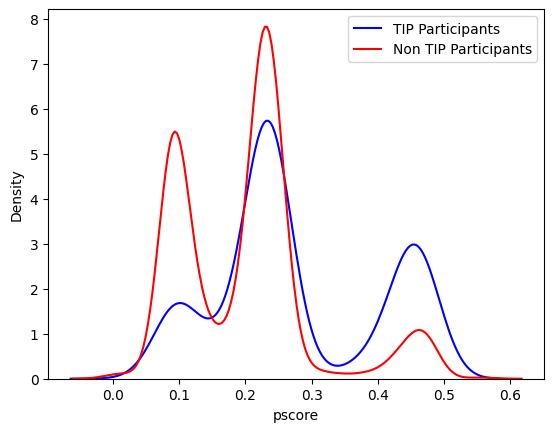

In [100]:
vars_to_check = [
    'year_TIP',
    'offense_before',
    'job_right_before_tip',
    'num_offenses_before',
    'earnings_two_years_prior'
]

X_psm = X_values[vars_to_check].copy()

psm_model = LogisticRegression()
psm_model.fit(X_psm, X_values['treatment'])

X_psm['pscore'] = psm_model.predict_proba(X_psm)[:, 1]
X_psm['treatment'] = X_values['treatment'].astype(int)

sns.kdeplot(X_psm[X_psm['treatment'] == 1]['pscore'], label='TIP Participants', color='blue')
sns.kdeplot(X_psm[X_psm['treatment'] == 0]['pscore'], label='Non TIP Participants', color='red')

plt.legend()

Given the diversity in propensity scores, it is best to use "caliper" matching to only match scores that are within a certain range of each other. This will help us to avoid matching participants with very different propensity scores, which could lead to biased results.

In [101]:
matched_exp['pscore'] = X_psm['pscore']

In [102]:
new_matched_exp = []
new_matched_treatment = []

matched_participant_pool = matched_exp[matched_exp['treatment'] == 0]

for tip_participant in matched_exp[matched_exp['treatment'] == 1].iterrows():
    tip_participant = tip_participant[1]
    matched_participants = matched_participant_pool[
        (matched_participant_pool['pscore'] >= tip_participant['pscore'] - 0.05) &
        (matched_participant_pool['pscore'] <= tip_participant['pscore'] + 0.05)
    ]
    if len(matched_participants) == 0:
        matched_participants = matched_participant_pool[
            (matched_participant_pool['pscore'] >= tip_participant['pscore'] - 0.1) &
            (matched_participant_pool['pscore'] <= tip_participant['pscore'] + 0.1)
        ]
    if len(matched_participants) == 0:
        continue

    cutoff = min(3, len(matched_participants))
    matched_participants = matched_participants.sample(cutoff, random_state=1).copy()
    matched_participant_pool = matched_participant_pool[
        (~matched_participant_pool['PCS_OFF_ID'].isin(matched_participants.dropna(subset=['PCS_OFF_ID'])['PCS_OFF_ID'])) &
        (~matched_participant_pool['interviewed_tip_id'].isin(matched_participants.dropna(subset=['interviewed_tip_id'])['interviewed_tip_id'])) 
    ]
    new_matched_exp.append(matched_participants)
    new_matched_treatment.append(tip_participant)

new_matched_exp = pd.concat(new_matched_exp, axis=0).drop_duplicates().reset_index(drop=True)
new_matched_treatment = pd.DataFrame(new_matched_treatment)

In [103]:
new_matched_exp = pd.concat([new_matched_exp, new_matched_treatment], axis=0).drop_duplicates().reset_index(drop=True)
new_matched_exp

,PCS_OFF_ID,interviewed_tip_id,matched_tip_id,race,gender,treatment_tip_id,treatment,num_offenses_before,earnings_year_prior,earnings_two_years_prior,job_right_before_tip,employment_outcome,employment_outcome_earnings,offense_outcome,year_start,pscore
0,1417950.0,NaN,474.0,Black,Male,NaN,0,1,0.0,0.0,0,0,0.0,True,2016,0.087646
1,1097794.0,NaN,1221.0,Black,Male,NaN,0,11,99281.0,271684.0,1,0,0.0,False,2020,0.123920
2,1907684.0,NaN,978.0,Black,Male,NaN,0,5,0.0,105666.0,0,0,0.0,False,2019,0.065986
3,663458.0,NaN,1486.0,White,Male,NaN,0,8,56544.0,56544.0,1,1,1280.0,False,2022,0.244372
4,NaN,2258.0,850.0,Black,Male,NaN,0,0,0.0,0.0,0,0,0.0,False,2018,0.231129
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2777,NaN,NaN,NaN,Black,Male,1764.0,1,2,0.0,0.0,0,1,54554.0,False,2023,0.082887
2778,NaN,NaN,NaN,Unknown,Unknown,1769.0,1,0,0.0,0.0,0,0,0.0,False,2023,0.215130
2779,NaN,NaN,NaN,Black,Male,1778.0,1,1,0.0,0.0,0,1,43947.0,False,2023,0.077846
2780,NaN,NaN,NaN,Black,Female,1779.0,1,0,0.0,0.0,0,0,0.0,False,2023,0.215130


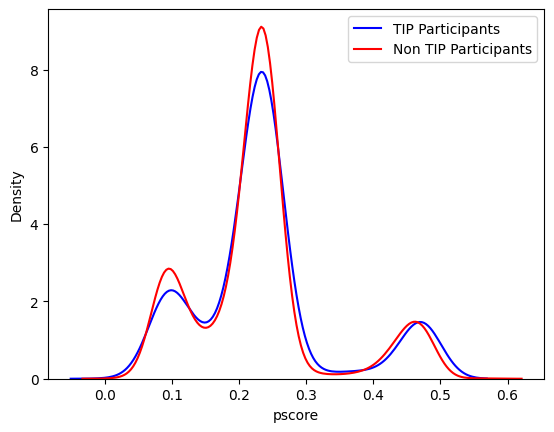

In [104]:
sns.kdeplot(new_matched_exp[new_matched_exp['treatment'] == 1]['pscore'], label='TIP Participants', color='blue')
sns.kdeplot(new_matched_exp[new_matched_exp['treatment'] == 0]['pscore'], label='Non TIP Participants', color='red')

plt.legend()

In [105]:
Y_has_employment = new_matched_exp['employment_outcome'].values

X_values = new_matched_exp[['treatment']].copy()
X_values['year_TIP'] = StandardScaler().fit_transform(new_matched_exp['year_start'].values.reshape(-1, 1))
# X_values['race_Black'] = (new_matched_exp['race'] == 'Black').astype(int)
# X_values['gender_Male'] = (new_matched_exp['gender'] == 'Male').astype(int)
X_values['offense_before'] = (new_matched_exp['num_offenses_before'] > 0).astype(int)

X_values['job_right_before_tip'] = new_matched_exp['job_right_before_tip'].astype(int)

X_values[['num_offenses_before']] = StandardScaler().fit_transform(new_matched_exp[['num_offenses_before']].values)
X_values[['earnings_two_years_prior']] = StandardScaler().fit_transform(new_matched_exp[['earnings_two_years_prior']].values)

# Interactions

X_values['treatment:year_TIP'] = X_values['treatment'] * X_values['year_TIP']
X_values['offense_before:treatment'] = X_values['offense_before'] * X_values['treatment']

vifs = []
for i in range(X_values.shape[1]):
    vif = variance_inflation_factor(X_values.values, i)
    vifs.append(vif)

vif_df = pd.DataFrame({'VIF': vifs}, index=X_values.columns)
vif_df

,VIF
treatment,1.671521
year_TIP,1.497468
offense_before,2.257716
job_right_before_tip,1.802267
num_offenses_before,1.617853
earnings_two_years_prior,1.311167
treatment:year_TIP,1.381395
offense_before:treatment,1.932833


In [106]:
X_values = sm.add_constant(X_values)
logit_has_employment = sm.Logit(Y_has_employment, X_values).fit()

logit_has_employment.summary()

Optimization terminated successfully.
         Current function value: 0.456145
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                      y   No. Observations:                 2782
Model:                          Logit   Df Residuals:                     2773
Method:                           MLE   Df Model:                            8
Date:                Thu, 12 Mar 2026   Pseudo R-squ.:                  0.3366
Time:                        17:16:03   Log-Likelihood:                -1269.0
converged:                       True   LL-Null:                       -1912.8
Covariance Type:            nonrobust   LLR p-value:                1.153e-272
============================================================================================
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                       -1.3085      0.088    -14.860      0.000      -1.481      -1.136
treatment                    1.0793      0.138      7.829      0.000       0.809       1.350
year_TIP                     0.4536      0.065      6.960      0.000       0.326       0.581
offense_before               0.2163      0.152      1.421      0.155      -0.082       0.515
job_right_before_tip         2.7764      0.148     18.766      0.000       2.486       3.066
num_offenses_before         -0.1041      0.069     -1.499      0.134      -0.240       0.032
earnings_two_years_prior     0.2389      0.113      2.112      0.035       0.017       0.461
treatment:year_TIP           0.6369      0.129      4.928      0.000       0.384       0.890
offense_before:treatment     0.2260      0.249      0.906      0.365      -0.263       0.715
============================================================================================
"""

Our model is as follows:

$$
\begin{aligned}
\text{logit}(p_i) = \;& \beta_0 + \beta_1 (\text{treatment}_i) 
\;+\; \beta_2 (\text{year\_TIP}_i) 
\;+\; \beta_3 (\text{offense\_before}_i) \\
& + \beta_4 (\text{job\_right\_before\_tip}_i)
+ \beta_5 (\text{num\_offenses\_before}_i)
+ \beta_6 (\text{earnings\_two\_years\_prior}_i) \\
& + \beta_7 (\text{treatment}_i \times \text{year\_TIP}_i)
+ \beta_8 (\text{offense\_before}_i \times \text{treatment}_i).
\end{aligned}
$$

- $\beta_1$ shows that at a baseline (Year = 2018, No Offense), participation with TIP increases the odds of employment by 2.91x. 
- $\beta_2$ shows that as years increase, we see a 54% increase in the odds of employment. (54% increase every 3.3 years)
- $\beta_4$ shows that having a job right before TIP increases the odds of employment by a massive 17x.
- $\beta_7$ shows that as years increase, as the years increase, we see a steeper increase in odds of employment for the treatment group (3x vs 1.5x). This suggests that TIP is becoming more effective over time, or that the participants are becoming more effective over time.

We see a strong positive association between TIP participation (treatment) and employment odds (around 3× higher odds for participants vs. controls), which becomes even stronger in later TIP years (rising to nearly 3× per additional year). Having a job right before TIP also sharply increases the odds of later employment. Meanwhile, accumulating prior offenses reduces the odds, and having a prior offense does not significantly alter the treatment effect

In [109]:
Y_offense = new_matched_exp['offense_outcome'].values
logit_has_offense = sm.Logit(Y_offense, X_values).fit()
logit_has_offense.summary()

Optimization terminated successfully.
         Current function value: 0.387231
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                      y   No. Observations:                 2782
Model:                          Logit   Df Residuals:                     2773
Method:                           MLE   Df Model:                            8
Date:                Thu, 12 Mar 2026   Pseudo R-squ.:                  0.1106
Time:                        17:16:52   Log-Likelihood:                -1077.3
converged:                       True   LL-Null:                       -1211.3
Covariance Type:            nonrobust   LLR p-value:                 2.590e-53
============================================================================================
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                       -1.0160      0.080    -12.780      0.000      -1.172      -0.860
treatment                   -2.0396      0.239     -8.527      0.000      -2.508      -1.571
year_TIP                     0.5425      0.071      7.678      0.000       0.404       0.681
offense_before              -2.0789      0.188    -11.056      0.000      -2.447      -1.710
job_right_before_tip         0.3702      0.136      2.725      0.006       0.104       0.637
num_offenses_before          0.2619      0.071      3.688      0.000       0.123       0.401
earnings_two_years_prior    -0.0038      0.055     -0.069      0.945      -0.112       0.104
treatment:year_TIP          -0.8350      0.175     -4.772      0.000      -1.178      -0.492
offense_before:treatment     2.5824      0.349      7.391      0.000       1.898       3.267
============================================================================================
"""

Our model is as follows:

$$
\begin{aligned}
\text{logit}(p_i) \;=\;& \beta_0 
\;+\; \beta_1(\text{treatment}_i) 
\;+\; \beta_2(\text{year\_TIP}_i) 
\;+\; \beta_3(\text{offense\_before}_i) 
\;+\; \beta_4(\text{job\_right\_before\_tip}_i)\\
&+\; \beta_5(\text{num\_offenses\_before}_i) 
\;+\; \beta_6(\text{earnings\_two\_years\_prior}_i)
\;+\; \beta_7(\text{treatment}_i \times \text{year\_TIP}_i)
\;+\; \beta_8(\text{offense\_before}_i \times \text{treatment}_i).
\end{aligned}
$$

This model is interesting - it seems to suggest that at a baseline, treatment does help reduce the probability of an Offense, and that this reduction has increased throughout the years. However, there is odd behavior where those with an offense before TIP have an increase in odds of having an offense if they do participate in TIP. 

In [110]:
new_matched_exp

,PCS_OFF_ID,interviewed_tip_id,matched_tip_id,race,gender,treatment_tip_id,treatment,num_offenses_before,earnings_year_prior,earnings_two_years_prior,job_right_before_tip,employment_outcome,employment_outcome_earnings,offense_outcome,year_start,pscore
0,1417950.0,NaN,474.0,Black,Male,NaN,0,1,0.0,0.0,0,0,0.0,True,2016,0.087646
1,1097794.0,NaN,1221.0,Black,Male,NaN,0,11,99281.0,271684.0,1,0,0.0,False,2020,0.123920
2,1907684.0,NaN,978.0,Black,Male,NaN,0,5,0.0,105666.0,0,0,0.0,False,2019,0.065986
3,663458.0,NaN,1486.0,White,Male,NaN,0,8,56544.0,56544.0,1,1,1280.0,False,2022,0.244372
4,NaN,2258.0,850.0,Black,Male,NaN,0,0,0.0,0.0,0,0,0.0,False,2018,0.231129
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2777,NaN,NaN,NaN,Black,Male,1764.0,1,2,0.0,0.0,0,1,54554.0,False,2023,0.082887
2778,NaN,NaN,NaN,Unknown,Unknown,1769.0,1,0,0.0,0.0,0,0,0.0,False,2023,0.215130
2779,NaN,NaN,NaN,Black,Male,1778.0,1,1,0.0,0.0,0,1,43947.0,False,2023,0.077846
2780,NaN,NaN,NaN,Black,Female,1779.0,1,0,0.0,0.0,0,0,0.0,False,2023,0.215130


In [111]:
recid = new_matched_exp[new_matched_exp['num_offenses_before'] > 0].copy()

Y_recid = recid['offense_outcome'].values
X_values = recid[['treatment']].copy()
X_values['year_TIP'] = StandardScaler().fit_transform(recid['year_start'].values.reshape(-1, 1))

X_values['offense_before'] = (recid['num_offenses_before'] > 0).astype(int)
X_values['job_right_before_tip'] = recid['job_right_before_tip'].astype(int)
X_values[['num_offenses_before']] = StandardScaler().fit_transform(recid[['num_offenses_before']].values)
X_values[['earnings_two_years_prior']] = StandardScaler().fit_transform(recid[['earnings_two_years_prior']].values)
X_values['treatment:year_TIP'] = X_values['treatment'] * X_values['year_TIP']

vifs = []
for i in range(X_values.shape[1]):
    vif = variance_inflation_factor(X_values.values, i)
    vifs.append(vif)

vif_df = pd.DataFrame({'VIF': vifs}, index=X_values.columns)
vif_df

,VIF
treatment,1.055889
year_TIP,1.473603
offense_before,2.477922
job_right_before_tip,1.397416
num_offenses_before,1.129818
earnings_two_years_prior,1.308388
treatment:year_TIP,1.347699


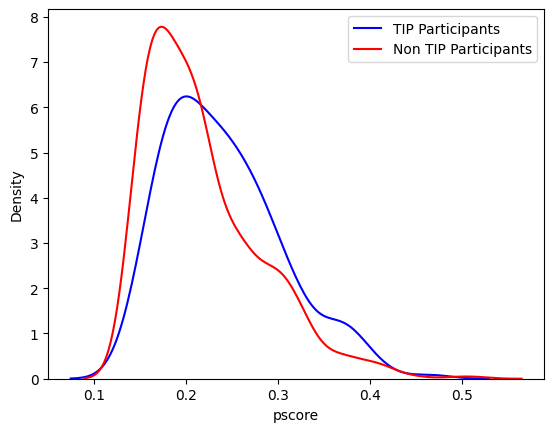

In [112]:
vars_to_check = [
    'year_TIP',
    'offense_before',
    'job_right_before_tip',
    'num_offenses_before',
    'earnings_two_years_prior'
]

X_psm = X_values[vars_to_check].copy()
psm_model = LogisticRegression()
psm_model.fit(X_psm, X_values['treatment'])
X_psm['pscore'] = psm_model.predict_proba(X_psm)[:, 1]
X_psm['treatment'] = X_values['treatment'].astype(int)

sns.kdeplot(X_psm[X_psm['treatment'] == 1]['pscore'], label='TIP Participants', color='blue')
sns.kdeplot(X_psm[X_psm['treatment'] == 0]['pscore'], label='Non TIP Participants', color='red')
plt.legend()

In [113]:
X_values = sm.add_constant(X_values)
logit_recid = sm.Logit(Y_recid, X_values).fit()
logit_recid.summary()

Optimization terminated successfully.
         Current function value: 0.289288
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                      y   No. Observations:                 1034
Model:                          Logit   Df Residuals:                     1027
Method:                           MLE   Df Model:                            6
Date:                Thu, 12 Mar 2026   Pseudo R-squ.:                 0.06400
Time:                        17:17:02   Log-Likelihood:                -299.12
converged:                       True   LL-Null:                       -319.58
Covariance Type:            nonrobust   LLR p-value:                 3.025e-07
============================================================================================
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
treatment                    0.0141      0.292      0.048      0.961      -0.557       0.586
year_TIP                    -0.6225      0.131     -4.747      0.000      -0.880      -0.365
offense_before              -2.6833      0.201    -13.375      0.000      -3.076      -2.290
job_right_before_tip         0.4837      0.278      1.740      0.082      -0.061       1.029
num_offenses_before          0.3088      0.093      3.324      0.001       0.127       0.491
earnings_two_years_prior    -0.0079      0.108     -0.073      0.942      -0.221       0.205
treatment:year_TIP          -0.0106      0.243     -0.044      0.965      -0.487       0.465
============================================================================================
"""

This model is not a strong predictor of whether or not someone will re-offend within 1.5 years of starting TIP. This makes sense, as we have far less data for later years.